<a href="https://colab.research.google.com/github/reem-1989/Cyberbullying-Detection-in-Syrian-Slang-By-Data-Mining/blob/main/Cyberbullying__Detection_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Detecting Cyberbullying in Comments of posts on Facebook
***

In [ ]:
!python --version

Python 3.7.12


Importing required Packages:

In [ ]:
import numpy as np #dealing with arrays
import pandas as pd #dealin with dataframes
import matplotlib.pyplot as plt #to visulaize the diagram
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, make_scorer
from time import time

from sklearn.naive_bayes import MultinomialNB # to build naive bayes model
from sklearn.tree import DecisionTreeClassifier # to build decision tree model
from sklearn.svm import LinearSVC # to build linearSVC Model
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier, BaggingClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.neighbors import KNeighborsClassifier
#from sklearn.externals import joblib
import warnings
warnings.filterwarnings('ignore')  # "error", "ignore", "always", "default", "module" or "once" "always"


Uploading Required  files and folders



In [ ]:
from google.colab import files
uploaded=files.upload()

Saving after upadte cyberbullying.xlsx to after upadte cyberbullying (1).xlsx


In [ ]:
import io
df=pd.read_excel(io.BytesIO(uploaded['after upadte cyberbullying.xlsx']))
df.head(30)

,comment,bullying
0,هههههههههه احلى شي,0
1,يا الله شو جلق وبايخ,12
2,الله يصطفل فيكي🙄🙄,2
3,ههههه #غباء,0
4,هيك شي 🙂www.eltsonlin.com,0
5,هههههههه,0
6,شو بتشبه الحردون,3
7,ليش عنجد الخبر@ali ali,0
8,تفاهة,12
9,متل حردون,3


In [ ]:
from google.colab import files
uploaded=files.upload()

Saving templates.zip to templates.zip


In [ ]:
from zipfile import ZipFile
file_name = "/content/templates.zip"
with ZipFile(file_name, 'r') as zip:
  zip.extractall()
  print('Done')

Done


In [ ]:
from google.colab import files
uploaded=files.upload()

Saving score.xlsx to score.xlsx


In [ ]:
import io
dfintensity=pd.read_excel(io.BytesIO(uploaded['score.xlsx']))
dfintensity.head(30)

,CyberbulledWord,score
0,كلب,0.5
1,تافه,0.5
2,سخيف,0.5
3,حيوان,0.5
4,خنزير,0.5
5,حتفك,0.3
6,كتير,0.1
7,جدا,0.1
8,علوي,0.4
9,كثير,0.1


In [ ]:
from google.colab import files
uploaded=files.upload()

Saving ARCyberbulling.owl to ARCyberbulling.owl


### Loading and Analyzing the data
***

In [ ]:
df.shape

(4235, 2)

plotting the Dataset

0    2311
1    1929
Name: bullying, dtype: int64


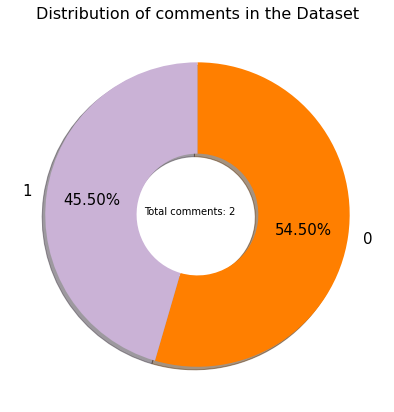

In [ ]:
plt.figure(figsize = (7,7))
sorted_counts = df['bullying'].value_counts()
print(sorted_counts)
plt.pie(sorted_counts, labels = sorted_counts.index, startangle = 90, counterclock = False, wedgeprops = {'width' : 0.6},
       autopct='%.2f%%', pctdistance = 0.7, textprops = {'color': 'black', 'fontsize' : 15}, shadow = True,
        colors = sns.color_palette("Paired")[7:])
plt.text(x = -0.35, y = 0, s = 'Total comments: {}'.format(df.shape[1]))
plt.title('Distribution of comments in the Dataset', fontsize = 16);

In [ ]:
df['bullying'] = df.bullying.map({'yes': 1, 'no': 0})

In [ ]:
df['bullying'] = df['bullying'].fillna(0).astype(np.int64)

In [ ]:
df.head()

,comment,bullying
0,هههههههههه احلى شي,0
1,يا الله شو جلق وبايخ,12
2,الله يصطفل فيكي🙄🙄,2
3,ههههه #غباء,0
4,هيك شي 🙂www.eltsonlin.com,0


In [ ]:
df.columns

Index(['comment', 'bullying'], dtype='object')

**Preprocessing the Data:**

Removing the arabic diacritics:

In [ ]:
import re
import string
import sys
import argparse
arabic_punctuations = '''`÷×؛<>_()*&^%][ـ،/:"؟.,'{}~¦+|!”…“–ـ'''
english_punctuations = string.punctuation
punctuations_list = arabic_punctuations + english_punctuations
print(punctuations_list)

`÷×؛<>_()*&^%][ـ،/:"؟.,'{}~¦+|!”…“–ـ!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~


In [ ]:
arabic_diacritics = re.compile("""
                             ّ    | # Tashdid
                             َ    | # Fatha
                             ً    | # Tanwin Fath
                             ُ    | # Damma
                             ٌ    | # Tanwin Damm
                             ِ    | # Kasra
                             ٍ    | # Tanwin Kasr
                             ْ    | # Sukun
                             ـ     # Tatwil/Kashida
                         """, re.VERBOSE)
print(arabic_diacritics)

re.compile('\n                             ّ    | # Tashdid\n                             َ    | # Fatha\n                             ً    | # Tanwin Fath\n                             ُ    | # Damma\n         , re.VERBOSE)


In [ ]:
def remove_diacritics(text):
    text = re.sub(arabic_diacritics, '', text)
    return text

In [ ]:
df['comment']=df['comment'].apply(remove_diacritics)
df['comment'][1793]

'طالع متل مصطيجة'

Removing the URL:

In [ ]:
import re
df['comment'] = df['comment'].str.replace('http\S+|www.\S+', '', case=False)
df['comment'][1702]

'زنخ'

Removing digits:

In [ ]:

from string import digits
def clean_digits(text):
 clean_text=''.join(filter(lambda x: not x.isdigit(),text))
 return clean_text

In [ ]:
df['comment']=df['comment'].apply(clean_digits)
df['comment'][188]

'الله  لا يكبرك'

Removing mensions:

In [ ]:
import re
def clean_mensions(text):
 mentions = re.findall("@([a-zA-Z0-9_]{1,50})", text)
 clean_text = re.sub("@[A-Za-z0-9_]+","", text)
 return clean_text

In [ ]:
df['comment']=df['comment'].apply(clean_mensions)
df['comment'][1708]

'سد حلقك 😒'

//Normalization The function unifies the orthography of alifs, hamzas, and yas/alif maqsuras. This is just a basic function that might need to be modified and expanded for specific purposes.

In [ ]:
def normalize_arabic(text):
    text = re.sub("[إأآا]", "ا", text)
    text = re.sub("ة", "ه", text)
    return text


In [ ]:
df['comment']=df['comment'].apply(normalize_arabic)
df.head()


,comment,bullying
0,هههههههههه احلى شي,0
1,يا الله شو جلق وبايخ,12
2,الله يصطفل فيكي🙄🙄,2
3,ههههه #غباء,0
4,هيك شي 🙂,0


Removing Punctuations:

In [ ]:
def remove_punctuations(text):
    translator = str.maketrans('', '', punctuations_list)
    return text.translate(translator)


In [ ]:
df['comment']=df['comment'].apply(remove_punctuations)
df['comment'][424]

'ههههههه مسخره وربي '

Removing repeating characters:

In [ ]:
def remove_repeating_char(text):
    return re.sub(r'(.)\1+', r'\1', text)


In [ ]:
df['comment']=df['comment'].apply(remove_repeating_char)
df['comment'][150]

'هوشه عرب ولو'

Removing symbols:

In [ ]:
import re
def clean_symbols(text):
 clean_text = re.sub('[؟?%#$]', '',text)
 return clean_text

In [ ]:
df['comment']=df['comment'].apply(clean_symbols)
df.head()

,comment,bullying
0,ه احلى شي,0
1,يا اله شو جلق وبايخ,12
2,اله يصطفل فيكي🙄,2
3,ه غباء,0
4,هيك شي 🙂,0


Removing nonarabic text:

In [ ]:
import string
def clean_nonarabic(text):
 text = "".join([char for char in text if char not in string.ascii_letters]).strip()
 return text

In [ ]:
df['comment']=df['comment'].apply(clean_nonarabic)
df['comment'][121]

'وصاحب الحديث كشاش 😂'

Removing emotion stickers:

In [ ]:
import re
def clean_Emoji(text):
    regrex_pattern = re.compile(pattern = "["
        u"\U0001F600-\U0001F64F"  # emoticons
        u"\U0001F300-\U0001F5FF"  # symbols & pictographs
        u"\U0001F680-\U0001F6FF"  # transport & map symbols
        u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
                           u"\U00002500-\U00002BEF"  # chinese char
                               u"\U00002702-\U000027B0"
                               u"\U00002702-\U000027B0"
                               u"\U000024C2-\U0001F251"
                               u"\U0001f926-\U0001f937"
                               u"\U00010000-\U0010ffff"
                               u"\u2640-\u2642"
                               u"\u2600-\u2B55"
                               u"\u200d"
                               u"\u23cf"
                               u"\u23e9"
                               u"\u231a"
                               u"\ufe0f"  # dingbats
                               u"\u3030"
                               "]+", flags=re.UNICODE)
    return regrex_pattern.sub(r'',text)

In [ ]:
df['comment']=df['comment'].apply(clean_Emoji)
df['comment']

0                   ه احلى شي
1         يا اله شو جلق وبايخ
2              اله يصطفل فيكي
3                      ه غباء
4                     هيك شي 
                ...          
4238      بصراحه سقطت من عيني
4239        انشاله سم الكراتي
4240    زهرمان البخاري انشاله
4241       يفرموكي فرم انشاله
4242               جربان مبين
Name: comment, Length: 4243, dtype: object

حذف التطويل باستخدام strip Tatwel

In [ ]:
import re
def strip_tatweel(text):
 TATWEEL = u"\u0640"
 clean_text = re.sub(TATWEEL, '', text)
 return  clean_text

In [ ]:
df['comment']=df['comment'].apply(strip_tatweel)
df['comment']

0                   ه احلى شي
1         يا اله شو جلق وبايخ
2              اله يصطفل فيكي
3                      ه غباء
4                     هيك شي 
                ...          
4238      بصراحه سقطت من عيني
4239        انشاله سم الكراتي
4240    زهرمان البخاري انشاله
4241       يفرموكي فرم انشاله
4242               جربان مبين
Name: comment, Length: 4243, dtype: object

Tokenization the text

In [ ]:
import nltk
nltk.download('punkt')
from nltk.tokenize import word_tokenize
def tokenize_text(text):
  tokens =word_tokenize(text)
  return tokens

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


In [ ]:
df['tokens']=df['comment'].apply(tokenize_text)
df['tokens']

0                   [ه, احلى, شي]
1       [يا, اله, شو, جلق, وبايخ]
2              [اله, يصطفل, فيكي]
3                       [ه, غباء]
4                       [هيك, شي]
                  ...            
4238     [بصراحه, سقطت, من, عيني]
4239        [انشاله, سم, الكراتي]
4240    [زهرمان, البخاري, انشاله]
4241       [يفرموكي, فرم, انشاله]
4242                [جربان, مبين]
Name: tokens, Length: 4243, dtype: object

In [ ]:
!pip install tashaphyne

     |████████████████████████████████| 251 kB 5.1 MB/s 
     |████████████████████████████████| 126 kB 44.6 MB/s 


In [ ]:
import pyarabic.arabrepr
from tashaphyne.stemming import ArabicLightStemmer
def stem_token(text):
  arepr = pyarabic.arabrepr.ArabicRepr()
  repr = arepr.repr
  ArListem = ArabicLightStemmer()
  stem = ArListem.light_stem(text)
  text=ArListem.get_root()
  return text


In [ ]:
word='بايخ'
print(stem_token(word))

بوخ


Building a customize stemmer for cyberbullying in Syrian Slang

In [ ]:
def stemming(text):
  dictionary = {'هالعاهره':'عاهره','هالعاهر':'عاهر','عاهرات':'عاهره','العاهرات':'عاهره','هالعاهرات':'عاهره','هالكلب':'كلب','هالكلبه':'كلبه','هالكلاب':'كلب','اكلبكون':'كلب','اكلب':'كلب','اتفهك':'تافه','اتفهكن':'تافه','اتفهكون':'تافه','ياتافه':'تافه','التافه':'تافه','التافهه':'تافه','السخيف':'سخيف','السخيفه':'سخيف'
  ,'اسخفك':'سخيف','اسخفك':'سخيف','ماسخفك':'سخيف','هالسخافه':'سخيف','الحيوان':'حيوان','الحيوانه':'حيوان','هالحيوان':'حيوان','هالحيوانه':'حيوان','ياحيوان':'حيوان','ياحيوانه':'حيوان','حيوانات':'حيوان','ماكلبكون':'كلب','ماتفهكون':'تافه','ماتفهكن':'تافه','الصرصور':'صرصور','الصراصير':'صرصور','صراصير':'صرصور','ياصرصور':'صرصور','هالجربان':'جربان','الجربان':'جربان','هالجربانه':'جربان','الجربانه':'جربان','الجرب':'جربان','جرب':'جربان','هالقرباطي':'قرباطي','القرباطي':'قرباطي','هالقرباطيه':'قرباطي','القرباطيه':'قرباطي','القرباطي':'قرباطي','القرباط':'قرباطي','هالنوري':'نوري','النوري':'نوري',
  'يامرتد':'مرتد','يامرتده':'مرتد','هالمرتد':'مرتد','هالمرتده':'مرتد','هالجلقه':'جلق','تنجلق':'جلق','تنجلقوا':'جلق','تنجلقو':'جلق','تنجلقي':'جلق','ياجلق':'جلق','ياجلقه':'جلق','جلقين':'جلق','ياجلقين':'جلق','ياشرموطه':'شرموطه','الشرموطه':'شرموطه','الشرمطه':'شرموطه','شرمطه':'شرموطه','ياشرموطه':'شرموطه','شراميط':'شرموطه','ياشراميط':'شرموطه','هالشرموطه':'شرموطه','هالشراميط':'شرموطه',
  'هالجلاقه':'جلق','يابايخ':'بايخ','يابايخه':'بايخ','هالبايخ':'بايخ','هالبايخه':'بايخ','هالبياخه':'بايخ','العمه':'العمى','يلعمه':'العمى','يحرئ':'يحرق','ينمحئ':'ينمحق','بيخري':'خرا','خرى':'خرا','اخرى':'خرا','بخري':'خرا','بتخري':'خرا','تفو':'تفي','تفيه':'تفي','اتفي':'تفي','تفه':'تفي','اتفه':'تفي','اتفو':'تفي','شاذه':'شاذ','سوده':'اسود','سودا':'اسود','هالاسود':'اسود','هالسوده':'اسود','هالسودا':'اسود','هالسود':'اسود','ياسود':'اسود','ياسوده':'اسود','ياسودا':'اسود',
  'تف':'تفي','شبيحا':'شبيح','هالشبيح':'شبيح','هالشبيحه':'شبيح','الشبيح':'شبيح','الشبيحه':'شبيح','هالتشبيح':'شبيح','ياشبيح':'شبيح','ياشبيحه':'شبيح','كزاب':'كذاب','ياكذاب':'كذاب','ياكذابه':'كذاب','هالكذب':'كذاب','هالكذاب':'كذاب','هالكذابه':'كذاب','اكذبك':'كذاب','اكذبكن':'كذاب','الكذاب':'كذاب','الكذابه':'كذاب','يغسلوا':'يغسل','ينغسل':'يغسل','بينغسل':'يغسل','بينغسلوا':'يغسل','يغسلو':'يغسل','بينغسلو':'يغسل',
  'كذابين':'كذاب','الكذابين':'كذاب','ماغلظك':'غليظ','ماغلظكون':'غليظ','غليز':'غليظ','غليزه':'غليظ','الغليظ':'غليظ','الغليظه':'غليظ','الخنزير':'خنزير','هالخنزير':'خنزير','خنزيره':'خنزير','هالخنزيره':'خنزير','ياخنزير':'خنزير','ياخنزيره':'خنزير','خنزره':'خنزير','الجردونه':'جردون','الجردون':'جردون','المنحرف':'منحرف','السود':'اسود','هالسواد':'اسود','السواد':'اسود','ءرد':'قرد','ءرده':'قرد','هالءرد':'قرد','هالءرده':'قرد','الءرد':'قرد','الءرده':'قرد',
  'هالمنحرفه':'منحرف','المنحرف':'منحرف','المنحرفه':'منحرف','هالانحراف':'منحرف','عالانحراف':'منحرف','هالشاذ':'شاذ','هالشاذه':'شاذ','هالشذوذ':'شاذ','ياشاذ':'شاذ','ياشاذه':'شاذ','هالبجم':'بجم','البجم':'بجم','يابجم':'بجم','النازح':'نازح','هالنازح':'نازح','يانازح':'نازح','نوازح':'نازح','هالنوازح':'نازح','هالنازحه':'نازح','يانازحه':'نازح','نازحين':'نازح','النازحين':'نازح','هالنازحين':'نازح','هالكلاب':'كلب','هالحمير':'حمار','اخرا':'خرا','اخرى':'خرا',
  'هالجردون':'جردون','هالجردونه':'جردون','هالجرادين':'جردون','الجرادين':'جردون','ياجردون':'جردون','ياجردونه':'جردون','ماغباك':'غبي','ماغباكي':'غبي','اغبى':'غبي','هالغبي':'غبي','هالغبيه':'غبي','عالغباء':'غبي','الغباء':'غبي','ياغبي':'غبي','ياغبيه':'غبي','غبا':'غبي','الغبا':'غبي','عالغبا':'غبي','هالغبا':'غبي','مبغله':'بغل','يابغل':'بغل','يابغله':'بغل','يابغال':'بغل','هالبغال':'بغل','مبغلين':'بغل','هالمبغلين':'بغل','مبغل':'بغل','المبغل':'بغل','المبغله':'بغل','هالمبغله':'بغل',
  'هالحردون':'حردون','هالحردونه':'حردون','هالحرادين':'حردون','الحرادين':'حردون','ياحردون':'حردون','ياحردونه':'حردون','الحردونه':'حردون','الحردون':'حردون','ماتفهك':'تافه','ماتفهكن':'تافه','ياتافه':'تافه','ياتافهه':'تافه','هالتافه':'تافه','هالتافهه':'تافه','هالتفاهه':'تافه','التافه':'تافه','التافهه':'تافه','عالتفاهه':'تافه','هالتفاهه':'تافه','تحورقو':'تحورق','تحورقي':'تحورق','تحورقوا':'تحورق','الشمبانزي':'شمبانزي','هالشمبانزي':'شمبانزي','المبغلين':'بغل','هالمبغل':'بغل','الجربانين':'جربان','هالجربانين':'جربان',
  'اجحشكن':'جحش','الجحش':'جحش','ياجحش':'جحش','جحشه':'جحش','الجحشه':'جحش','جحشنه':'جحش','الجحشنه':'جحش','اجحش':'جحش','تجحشن':'جحش','تجحشني':'جحش','تجحشنو':'جحش','تجحشنوا':'جحش','ياكر':'كر','جحيش':'جحش','تجحش':'جحش','هالحرام':'حرام','الحرام':'حرام','هالحمار':'حمار','هالحمير':'حمار','هالحماره':'حمار','ياحمار':'حمار','ياحماره':'حمار','هالحرامي':'حرامي','الحرامي':'حرامي','حراميه':'حرامي','الحراميه':'حرامي','حرميه':'حرامي','سراق':'حرامي','هالحراميه':'حرامي','ياحرامي':'حرامي','ياحراميه':'حرامي','هالصلعه':'اصلع','الصلعه':'اصلع','صلعتو':'اصلع','عالصلعه':'اصلع','ياكلب':'كلب','ياكلبه':'كلب','الصلعه':'اصلع',
  'هالاندبوري':'اندبوري','الاندبوري':'اندبوري','هالاندبوريه':'اندبوري','الاندبوريه':'اندبوري','يلعنلك':'يلعن','يلعنكون':'يلعن','يلعنكن':'يلعن','يلعنك':'يلعن','يلعنكم':'يلعن','العن':'يلعن','لعنه':'يلعن','لعين':'يلعن','اندل':'ندل','الندل':'ندل','الندله':'ندل','اندلون':'ندل','ماندلون':'ندل','اندال':'ندل','هالاندال':'ندل','هالندله':'ندل','ياندل':'ندل','ياندله':'ندل','يااندال':'ندل','ندلين':'ندل','الندلين':'ندل','هالندلين':'ندل','هالتافهين':'تافه','التافهين':'تافه','هالفيلبينيه':'فيلبيني','الفليبين':'فيلبيني','الفيلبيني':'فيلبيني','يافليبيني':'فيلبيني','هالفيلبيني':'فيلبيني','سرلنكيه':'سيرلينكي','السرلينكي':'سيرلينكي','السيرلنكيه':'سيرلينكي','هالسيرلنكي':'سيرلينكي',
  'الحقير':'حقير','الحقيره':'حقير','هالحقير':'حقير','هالحقيره':'حقير','عالحقاره':'حقير','الحقاره':'حقير','احقر':'حقير','حئير':'حقير','حئيره':'حقير','حئيرين':'حقير','حقيرين':'حقير','ماحقرك':'حقير','ماحقركن':'حقير','ياحقير':'حقير','ياحقيره':'حقير','شوهالحقاره':'حقير','العايبه':'عايبه','هالعايبه':'عايبه','ياعايبه':'عايبه','الكشاش':'كشاش','هالكشاش':'كشاش','الكشاشه':'كشاش','هالكشاشه':'كشاش','ياكشاش':'كشاش','ياكشاشه':'كشاش','كش':'كشاش','ماكشك':'كشاش','سدو':'سد','سدي':'سد','سديه':'سد',
  'سدوه':'سد','اخرسي':'سد','خراس':'سد','اخرس':'سد','سكوت':'سد','اسكت':'سد','سكتي':'سد','اسكتي':'سد','خرسو':'سد','اخرسو':'سد','اسكتو':'سد','سكتو':'سد','عرص':'عرصه','هالعرص':'عرصه','عرصا':'عرصه','هالعرصا':'عرصه','اعرص':'عرصه','تعريص':'عرصه','عرصات':'عرصه','ياعرص':'عرصه','ياعرصه':'عرصه','ياعرصا':'عرصه','ياعرصات':'عرصه','هالعرص':'عرصه','هالعرصا':'عرصه','هالعرصه':'عرصه','عرصيص':'عرصه','مصفاي':'مصفي','مصفايه':'مصفي',
  'الحنش':'حنش','ياحنش':'حنش','يحنشو':'حنش','تحنيش':'حنش','هالحنش':'حنش','بقره':'بقر','البقره':'بقر','هالبقره':'بقر','ابقر':'بقر','البقر':'بقر','':'بقر','':'بقر','ابقركن':'بقر','يابقر':'بقر','يابقره':'بقر','الفواحش':'فواحش','الفاحشه':'فواحش','الفحشاء':'فواحش','فحشاء':'فواحش','الديوث':'ديوث','الكبير':'كبير','هالبهيم':'بهيم','هالبهيمه':'بهيم','هالبهايم':'بهيم','يابهيم':'بهيم','يابهيمه':'بهيم','الظراطه':'ظراطه','الزراطه':'ظراطه','ياظراطه':'ظراطه','يازراطه':'ظراطه','شوظراطه':'ظراطه','شوزراطه':'ظراطه','المقورن':'مقورن','عهالصلعه':'اصلع',
  'بندوء':'بندوق','مبندق':'بندوق','بندوقين':'بندوق','مبندقين':'بندوق','بندقه':'بندوق','بناديق':'بندوق','يابندوءه':'بندوق','هالبندوء':'بندوق','هالبندوق':'بندوق','هالمبندق':'بندوق','هالمبندء':'بندوق','البندوق':'بندوق','يابندوق':'بندوق','بندوقه':'بندوق','بندوءه':'بندوق','هالمحورقه':'محورق','يامحورق':'محورق','يامحورقه':'محورق','مقورنه':'مقورن','المقورنه':'مقورن','يامقورنه':'مقورن','هالمقورنه':'مقورن','قرون':'مقورن','هالقرون':'مقورن','القفا':'قفا','ابورياله':'رياله','تحيونو':'حيوان','تحيونوا':'حيوان','تحيون':'حيوان',
  'الواطي':'واطي','الواطيه':'واطي','وطاوه':'واطي','واطيين':'واطي','هالواطي':'واطي','هالواطيه':'واطي','السافل':'سافل','السافله':'سافل','هالسافله':'سافل','هالسافل':'سافل','السفله':'سافل','سفله':'سافل','الكديش':'كديش','الكديشه':'كديش','هالكديش':'كديش','هالكديشه':'كديش','هالمقورن':'مقورن','شومقورن':'مقورن','محورء':'محورق','محورقه':'محورق','محورقه':'محورق','المحورق':'محورق','هالمحورق':'محورق','هالمحورء':'محورق','المبهدل':'مبهدل','المبهدله':'مبهدل','يامبهدله':'مبهدل','عالبهدله':'مبهدل',
  'الفاشل':'فاشل','الفاشله':'فاشل','الفشل':'فاشل','هالفاشل':'فاشل','هالفاشله':'فاشل','يافاشل':'فاشل','يافاشله':'فاشل','المتخلف':'متخلف','هالمتخلف':'متخلف','المتخلفه':'متخلف','هالمتخلفه':'متخلف','التخلف':'متخلف','يامتخلف':'متخلف','يامتخلفه':'متخلف','هالتخلف':'متخلف','البغل':'بغل','البغله':'بغل','هالبغله':'بغل','مبغل':'بغل','يابغله':'بغل','هالبغال':'بغل','البغال':'بغل','مابغلك':'بغل','مابغلكن':'بغل','ابغل':'بغل','ديوس':'ديوث','الديوس':'ديوس','هالمبهدل':'مبهدل','هالمبهدله':'مبهدل','هالبهدله':'مبهدل','مبغله':'بغل',
  'الزومبي':'زومبي','الوسخ':'وسخ','هالوسخ':'وسخ','الوسخه':'وسخ','هالوسخه':'وسخ','الوساخه':'وسخ','عالوساخه':'وسخ','هالوساخه':'وسخ','اوسخ':'وسخ','وسخنه':'وسخ','عالوسخنه':'وسخ','هالوسخنه':'وسخ','ماوسخكن':'وسخ','ماوسخك':'وسخ','هالعكروت':'عكروت','العكروت':'عكروت','العكروته':'عكروت','هالعكروته':'عكروت','ماكرهك':'كريه','ماكرهكن':'كريه','شوكريه':'كريه','شوكريهه':'كريه','ياكره':'كريه','ياكريهه':'كريه','اغبى':'غبي','قديش':'كديش','ياقديش':'كديش','القديش':'كديش','هالفجعان':'فجعان','هالفجعانه':'فجعان','فجعانين':'فجعان','الفجعانين':'فجعان','الفجع':'فجعان','عالفجع':'فجعان','النوته':'نوته','هالنوته':'نوته','يانوته':'نوته','شونوته':'نوته',
  'الحصان':'حصان','هالحصان':'حصان','ياحصان':'حصان','هالحشره':'حشره','الحشره':'حشره','حشرات':'حشره','هالحشرات':'حشره','ياحشرات':'حشره','هالمختل':'مختل','هالمختله':'مختل','هالزنوج':'زنجي','الزنجي':'زنجي','الزنجيه':'زنجي','يازنجي':'زنجي','يازنجيه':'زنجي','هالزنجيه':'زنجي','المقرف':'مقرف','المقرفه':'مقرف','ماقرفك':'مقرف','اقرف':'مقرف','اقرفك':'مقرف','ماقرفكن':'مقرف','ماقرفك':'مقرف','بتقرف':'مقرف','بيقرف':'مقرف','يامقرف':'مقرف','شومقرف':'مقرف','يامقرفه':'مقرف','الكركم':'كركم','هالكركم':'كركم','ياكركم':'كركم','كركمه':'كركم','هالكركمه':'كركم','الكركمه':'كركم','ياكركم':'كركم','البخيل':'بخيل','هالبخيل':'بخيل','بخيله':'بخيل','البخيله':'بخيل','هالبخيله':'بخيل','يابخيل':'بخيل','يابخيله':'بخيل','عالبخل':'بخيل','بخل':'بخيل','البخل':'بخيل','تعريصكن':'عرصه',
  'هالصرمايه':'صرمايه','هالصرماي':'صرمايه','صرامي':'صرمايه','صرماي':'صرمايه','الساقطه':'ساقط','الساقط':'ساقط','هالساقط':'ساقط','هالساقطه':'ساقط','سقاطه':'ساقط','صاقطه':'ساقط','الصاقطه':'ساقط','هالصاقطه':'ساقطه','ياساقط':'ساقطه','ياساقطه':'ساقط','الساقطين':'ساقط','هالساقطين':'ساقط','ساقطين':'ساقط','ياساقطين':'ساقط','النيغر':'نيغر','يانيغر':'نيغر','الغاي':'غاي','هالغاي':'غاي','الاسود':'اسود','هالاسود':'اسود','هالسودا':'اسود','هالسوده':'اسود','سواد':'اسود','هالسواد':'اسود','هالهندي':'هندي','هالهنديه':'هندي','ياهندي':'هندي','ياهنديه':'هندي','الهنود':'هندي','هالهنود':'هندي','هالسوداني':'سوداني','هالسودانيه':'سوداني','ياسوداني':'سوداني','ياسودانيه':'سوداني','هالصومالي':'صومالي','هالصوماليه':'صومالي','الصومالي':'صومالي','الصوماليه':'صومالي','صوماليين':'صومالي','ياصومالي':'صومالي','ياصوماليه':'صومالي','سودانيه':'سوداني','صوماليه':'صومالي',
  'الشاطوحه':'شاطوحه','هالشاطوحه':'شاطوحه','ياشاطوحه':'شاطوحه','شوشاطوحه':'شاطوحه','الشاحوطه':'شاحوطه','هالشاحوطه':'شاحوطه','ياشاحوطه':'شاحوطه','الاجدب':'اجدب','الجدبه':'اجدب','ماجدبا':'اجدب','ماجدبكن':'اجدب','ماجدبك':'اجدب','ماجدبك':'اجدب','هالاجدب':'اجدب','ياجدبه':'اجدب','المصيف':'مصيف','المصيفه':'مصيف','يامصيف':'مصيف','يامصيفه':'مصيف','هالاهتر':'اهتر','هالهتره':'اهتر','الاهتر':'اهتر','الهتره':'اهتر','هالنمس':'نمس','يانمس':'نمس','النس':'نس','هالنس':'نس','هالسهيان':'سهيان','هالسهيانه':'سهيان','هالسلال':'سلال','هالسلاله':'سلال','النسنسه':'نسناس','هالنسنسه':'نسناس','النسنسه':'نسناس','الرعب':'مرعب','هالرعب':'مرعب','تستحي':'استحي','بيستحي':'استحي','بتستحي':'استحي','مابيستحوا':'استحي','مابتستحي':'استحي','مابيستحي':'استحي','استحو':'استحي','مستحا':'استحي','تستهزئ':'استهزاء','يستهزئ':'استهزاء','البيطري':'بيطري','البيطره':'بيطره','بيطره':'بيطري','الشوام':'شوام','شامي':'شوام','شاميه':'شوام','الشامي':'شوام','دمشقي':'شامي',
  'الفاسد':'فاسد','هالفاسد':'فاسد','الفاسدين':'فاسد','يافاسد':'فاسد','يافاسده':'فاسد','هالفاسده':'فاسد','الفساد':'فاسد','الجاجه':'جاجه','هالجاجه':'جاجه','ياجاجه':'جاجه','هالمصروع':'مصروع','المصروع':'مصروع','هالمصروعه':'مصروع','يامصروع':'مصروع','يامصروعه':'مصروع','هالشرنه':'شرنه','الشرنه':'شرنه','ياشرنه':'شرنه','شرن':'شرنه','ياشرن':'شرنه','شوشرنه':'شرنه','هالشاضومه':'شاضومه','ياشاضومه':'شاضومه','الشاضومه':'شاضومه','هالمتصنع':'متصنع','يامتصنع':'متصنع','جامده':'جامد','هالجامد':'جامد','هالجامده':'جامد','جمود':'جامد','الجمود':'جامد','ناشفه':'ناشف','نشفان':'ناشف','النشفان':'ناشف','ياجامد':'جامد','المربع':'مربع','تربيع':'مربع','التربيع':'مربع','المربعه':'مربع','مربعه':'مربع','مهوسه':'مهوس','هالمهوسه':'مهوس','هالمهوس':'مهوس','هوس':'مهوس','الهوس':'مهوس','طنطات':'طنط','الطنط':'طنط','هالطنط':'طنط','ياطنط':'طنط','الطرطور':'طرطور','هالطرطور':'طرطور','طرطوره':'طرطور','هالطرطوره':'طرطور','ياطرطور':'طرطور','ياطرطوره':'طرطور','طراطير':'طرطور','الطراطير':'طرطور','هالطراطير':'طرطور','ياطراطير':'طرطور','ضرابه':'ضراب','الحريم':'حريمه','ياحريمه':'حريمه',
  'هالمتصنعه':'متصنع','يامتصنعه':'متصنع','عالتصنع':'متصنع','تصنع':'متصنع','التصنع':'متصنع','الوضيع':'وضيع','الوضيعه':'وضيع','هالوضيع':'وضيع','هالوضيع':'وضيع','وضاعه':'وضيع','عالجومسه':'جاموس','القبيح':'قبيح','القبيحه':'قبيح','هالقبيح':'قبيح','هالقبيحه':'قبيح','القباحه':'قبيح','قبح':'قبيح','القبح':'قبيح','عالقبح':'قبيح','اقبح':'قبيح','ماقبحك':'قبيح','ماقبحكن':'قبيح','ياقبيح':'قبيح','ياقبيحه':'قبيح','فشرت':'فشر','فشرتي':'فشر','فشرو':'فشر','هالعلاك':'علاك','هالعلاكه':'علاك','العلاك':'علاك','العلاكه':'علاك','العلاكين':'علاك','عالعلاكين':'علاك','هالعلاكين':'علاك','هالعاطل':'عاطل','عاطله':'عاطل','هالعاطله':'عاطل','معتوهه':'معتوه','هالمعتوهه':'معتوه','المعتوهه':'معتوه','هالمعتوه':'معتوه','يامعتوه':'معتوه','يامعتوهه':'معتوه','الندل':'ندل','هالندل':'ندل','اندل':'ندل','المنغولي':'منغولي','هالمنغولي':'منغولي','منغوليه':'منغولي','هالمنغوليه':'منغولي','يامنغولي':'منغولي','يامنغوليه':'منغولي','ياخده':'ياخدك','ياخدها':'ياخدك','ياخدا':'ياخدك','قرده':'قرد','ياقرده':'قرد','القرود':'قرد','المعزايات':'معزايه','هالمعزايه':'معزايه','هالمعزايات':'معزايه','يامعزايه':'معزايه','ماع':'معزايه','يقطعكوا':'يقطعك','هالمسيحي':'مسيحي','المسيحيه':'مسيحي','المسيحين':'مسيحي',
  'عالوضاعه':'وضيع','هالوضاعه':'وضيع','المفتوق':'مفتوق','هالمفتوق':'مفتوق','ينئصف':'ينقصف','هالحلزون':'حلزون','هالحلزونه':'حلزون','ياحلزون':'حلزون','ياحلزونه':'حلزون','ناقصه':'ناقص','عاطلين':'عاطل','هالعاطلين':'عاطل','يشبعكن':'يشبعك','يشبعكون':'يشبعك','يخليكن':'يخليك','هالقرد':'قرد','القرد':'قرد','هالقرده':'قرد','القرد':'قرد','القرده':'قرد','القرود':'قرد','القرده':'قرد','يكسركن':'يكسر','يجبركن':'يجبر','يشبعكن':'يشبعك','يفطسكن':'يفطس','يفطسو':'يفطس','تفطسي':'يفطس','تفطسو':'يفطس','بيفطس':'يفطس','بتفطس':'يفطس','هالوخمه':'وخمه','الوخمه':'وخمه','ياوخمه':'وخمه','عالوخامه':'وخمه','المدهرنه':'مدهرنه','يامدهرنه':'مدهرنه','الوخمه':'وخمه','الوخامه':'وخمه','الاندال':'ندل','هالاندال':'ندل','ياندل':'ندل','ياندال':'ندل','هالاندال':'ندل','هالكمخ':'كمخ','ماكمخك':'كمخ','ماكمخكن':'كمخ','هالكمخه':'كمخ','يوفقكن':'يوفقك','لايفهم':'مابيفهم','مابتفهم':'مابيفهم','مابيفهمو':'مابيفهم','مابتفهمو':'مابيفهم','كالحمار':'حمار','كالجحش':'جحش','كالكديش':'كديش','القرده':'قرد','هالقرود':'قرد','هالمعزايه':'معزايه ','يامعزايه':'معزايه ',
  'هالناقص':'ناقص','هالدنيء':'دنيء','هالدناوه':'دنيء','دناوه':'دنيء','هالدنيئه':'دنيء','دناءه':'دنيء','هالدناءه':'دنيء','عاللجوء':'لاجئ','اللاجئ':'لاجئ','اللاجئه':'لاجئ','لجوء':'لاجئ','اللجوء':'لاجئ','العنصريه':'عنصري','العنصري':'عنصري','ياعنصريه':'عنصري','ياعنصري':'عنصري','هالمتعجرف':'متعجرف','المتعجرف':'متعجرف','هالمتعجرفه':'متعجرف','المتعجرفه':'متعجرف','التعجرف':'متعجرف','عالتعجرف':'متعجرف','هالاناني':'اناني','هالانانيه':'اناني','انانيه':'اناني','عالانانيه':'اناني','المغرور':'مغرور','المغروره':'مغرور','هالمغرور':'مغرور','هالمغروره':'مغرور','عالغرور':'مغرور','هالجاموس':'جاموس','الجاموس':'جاموس','يجومس':'جاموس','هالوقح':'وقح','الوقح':'وقح','هالوقحه':'وقح','الوقحه':'وقح','ياوقح':'وقح','ياوقحه':'وقح','اوقح':'وقح','ماوقحك':'وقح','ماوقحكن':'وقح','عالوقاحه':'وقح','هالوقاحه':'وقح','ياوقح':'وقح','ياوقحه':'وقح','وقحين':'وقح','وقاحه':'وقح','هالسمج':'سمج','هالسمجه':'سمج','يردكن':'يردك','يردكم':'يردك','صرمايتي':'صرمايه','عصرمايتي':'صرمايه','لصرمايتي':'صرمايه','لكندرتي':'كندره','عكندرتي':'كندره','لرجلي':'رجل','عرجلي':'رجل','هالمسيحيه':'مسيحي','تكفر':'كافر','تكفرو':'كافر','يكفر':'كافر','يكفرو':'كافر','هالكافر':'كافر','الكافر':'كافر','ياكافر':'كافر','مهالمعارض':'معارض',
  'ماتقل':'تقيل','ثقيل':'تقيل','اتقل':'تقيل','يقطعكن':'يقطعك','هالمهزله':'مهزله','المهزله':'مهزله','هالحرباي':'حربايه','هالحربايه':'حربايه','ياحربايه':'حربايه','بخوف':'مخيف','بتخوف':'مخيف','بخوفو':'مخيف','بخوفوا':'مخيف','بيخوفو':'مخيف','بتخوفو':'مخيف','بفزع':'فزيعه','بتفزع':'فزيعه','بفزعو':'فزيعه','بتفزعو':'فزيعه','بيفزعو':'فزيعه','هالفزيعه':'فزيعه','هالفزاعه':'فزيعه','انقبري':'انقبر','نقبرو':'انقبر','انقبرو':'انقبر','تنقبرو':'انقبر','ينقبرو':'انقبر','ياعاهه':'عاهه','ياعاهات':'عاهه','ذنب':'دنب','هالدنب':'دنب','يادنب':'دنب','ديل':'دنب','ياديل':'دنب','هالثرثار':'ثرثار','الثرثار':'ثرثار','ياثرثار':'ثرثار','الثرثاره':'ثرثار','ثرثره':'ثرثار','هالثرثاره':'ثرثار','ماندل':'ندل','ماندلك':'ندل','ماندلكن':'ندل','ندله':'ندل','اندال':'ندل','الوطي':'لوطي','هالوطي':'لوطي','يالوطي':'لوطي','الواطه':'لوطي','السحاق':'سحاقيه','مثليه':'مثلي','المثلي':'مثلي','المثليه':'مثلي','المثليين':'مثلي','ءحبه':'قحبه','دينك':'دين','دينكن':'دين','الدين':'دين','هالدين':'دين','دينكم':'دين','ماقذرك':'قذر','ماقذركن':'قذر','ماقذركم':'قذر','ماميعك':'مايع','ماميعكن':'مايع','ماصيعك':'صايع','ماصيعكن':'صايع','يطءلك':'يطقلك','يطءلكن':'يطقلك','يطءلكون':'يطقلك','يطقلكون':'يطقلك','يطقلكن':'يطقلك','هالمعارضه':'معارض','المعارض':'معارض','المعارضه':'معارض','يامعارض':'معارض','المعارضين':'معارض','هالمعارضين':'معارض','يامعارضين':'معارض','يامعارضه':'معارض','المندسه':'مندس',
  'المشلول':'مشلول','هالمشلول':'مشلول','المشلوله':'مشلول','هالمشلوله':'مشلول','يامشلول':'مشلول','يامشلوله':'مشلول','شلل':'مشلول','رخيصه':'رخيص','الرخيصه':'رخيص','هالرخيص':'رخيص','هالرخيصه':'رخيص','مارخصك':'رخيص','مارخصكن':'رخيص','ارخص':'رخيص','يارخيص':'رخيص','يارخيصه':'رخيص','ترخصي':'رخيص','ترخصو':'رخيص','يرخصو':'رخيص','هالحويتري':'حويتري','ياحويتري':'حويتري','الحويتري':'حويتري','حويتريه':'حويتري','الحويتريه':'حويتري','هالحويتريه':'حويتري','عاهات':'عاهه','هالعاهه':'عاهه','الداعره':'داعره','هالداعره':'داعره','ياداعره':'داعره','داعر':'داعره','ياداعره':'داعره','دعاره':'داعره','النرجسي':'نرجسي','النرجسيه':'نرجسي','هالنرجسيه':'نرجسي','المتكبر':'متكبر','هالمتكبر':'متكبر','يامتكبر':'متكبر','يامتكبره':'متكبر','هالمتكبره':'متكبر','المتكبره':'متكبر','التكبر':'متكبر','عالتكبر':'متكبر','الغيره':'غيور','عالغيره':'غيور','الغيور':'غيور','بغار':'غيور','بتغار':'غيور','بغارو':'غيور','بتغارو':'غيور','هالغيوره':'غيور','الغيوره':'غيور','ياغيوره':'غيور','تخوزقو':'تخوزق','تخوزقنا':'تخوزق','تخوزقت':'تخوزق','مازنخك':'زنخ','مازنخكن':'زنخ','مابلدك':'بليد','مابلدكن':'بليد','سودانين':'سوداني','السودانين':'سوداني','هالسودانين':'سوداني','هالصومالين':'صومالي','صوماليه':'صومالي','الصوماليه':'صومالي','السودانيه':'سوداني','السودانيه':'سوداني','يجبركن':'يجبرك','الصومالين':'صومالي','العرب':'عرب','هالعربي':'عرب','هالعربيه':'عرب','العربي':'عرب','العربيه':'عرب','فهيم':'مابيفهم',
  'هالسماجه':'سمج','عالسماجه':'سمج','ماسمجك':'سمج','اسمج':'سمج','ماسمجكن':'سمج','ياسمج':'سمج','السماجه':'سمج','ياسمجه':'سمج','هالسءيل':'سءيل','هالسءيله':'سءيل','السءيل':'سءيل','السءيله':'سءيل','عالسءاله':'سءيل','هالسءاله':'سءيل','ماسءلك':'سءيل','ماسءلكن':'سءيل','ياسءيل':'سءيل','اسءل':'سءيل','هالفلتانه':'فلتان','الفلتانه':'فلتان','هالفلتان':'فلتان','الفلتان':'فلتان','فلتنه':'فلتان','عالفلتنه':'فلتان','يافلتانه':'فلتان','مافلتك':'فلتان','افلت':'فلتان','بسفالتك':'سافل','بينطاق':'بتنطاق','بطيقك':'بتنطاق','بطيقو':'بتنطاق','مابطيقو':'بتنطاق','مابطيقك':'بتنطاق','مابتنطاقي':'بتنطاق','مابطيقكن':'بتنطاق','مابتنطاقو':'بتنطاق','مابينطاقو':'بتنطاق','يانرجسي':'نرجسي','يانرجسيه':'نرجسي','نرجسين':'نرجسي','يانرجسين':'نرجسي','هالنرجسين':'نرجسي','كبو':'كب','النسونجي':'نسونجي','هالنسونجي':'نسونجي','يانسونجي':'نسونجي','الءيم':'لءيم','الءيمه':'لءيم','هالءيم':'لءيم','هالءيمه':'لءيم','لءامه':'لءيم','يالءيم':'لءيم','يالءيمه':'لءيم','القميء':'قميء','القميءه':'قميء','هالقميءه':'قميء','هالقميء':'قميء','قماءه':'قميء','بتخرو':'خرا','بيخرو':'خرا','ءارح':'قارح','ءارحه':'قارح','ءارحين':'قارح','قارحين':'قارح','هالقارحه':'قارح','هالءارحه':'قارح','هالءارحين':'قارح',
  'هالنورنه':'نوري','النورنه':'نوري','يانوري':'نوري','هالنوريه':'نوري','النوريه':'نوري','مانورك':'نوري','مانوركن':'نوري','يانوري':'نوري','يانوريه':'نوري','التور':'تور','هالتور':'تور','ثور':'تور','الثور':'تور','الحيه':'حيه','هالحيه':'حيه','ياحيه':'حيه','حيايا':'حيه','تس':'حيه','التس':'حيه','هالزقايقي':'زقايقي','الزقايقي':'زقايقي','الزقاقيه':'زقايقي','هالزقاقيه':'زقايقي','يازقاقي':'زقايقي','الصئايئي':'صئايئي','هالصائيئي':'صئايئي','صئائيه':'صئايئي','هالصئائيه':'صئايئي','القديش':'كديش','لاترخص':'رخيص','لاترخصي':'رخيص','لاترخصو':'رخيص','هالدب':'دب','هالدبه':'دب','الدب':'دب','يادب':'دب','يادبه':'دب','هالمدبدبه':'دب','مدبدب':'دب','المدبدبه':'دب','الرذيله':'رذيله','للرذيله':'رذيله','رذيل':'رذيله','رذيل':'رذيله','رزيله':'رذيله','مءوصه':'مءوص','مقوصه':'مءوص','يامءوصه':'مءوص','يامئوص':'مءوص','المعاق':'معاق','المعاقه':'معاق','اعاقه':'معاق','هالمعاق':'معاق','هالمعاقه':'معاق','يءصفو':'يقصف','يءصف':'يقصف','يقصفو':'يقصف','سيءه':'سيء','السيءه':'سيء','هالسيء':'سيء','هالسيءه':'سيء','ياسيء':'سيء','ياسيءه':'سيء','شمءرين':'شمقرين','هالشمءرين':'شمقرين','ياشمءرين':'شمقرين','الشمءرين':'شمقرين','ءله':'قله','ماهبلك':'اهبل','ماهبلكن':'اهبل','ماشرشحك':'شرشوح','ماشرشحكن':'شرشوح','الهنود':'هندي','المندس':'مندس','هالمندس':'مندس','هالمندسه':'مندس','المندسين':'مندس','هالمندسين':'مندس','يامندس':'مندس','يامندسه':'مندس','يامندسين':'مندس','عربي':'عرب',
  'اضبضبو':'اضبضب','اضبضبوا':'اضبضب','تنطرشو':'تنطرش','ينطرشو':'تنطرش','ينطرش':'تنطرش','تتفزلكو':'فزلكه','يتفزلكو':'فزلكه','هالضفدع':'ضفدع','الضفدع':'ضفدع','ياضفدع':'ضفدع','ضفدعه':'ضفدع','هالضفدعه':'ضفدع','ياضفدعه':'ضفدع','مضفدعه':'ضفدع','الضفدعه':'ضفدع','عالضفدعه':'ضفدع','الضفادع':'ضفدع','عالضفادع':'ضفدع','المعفن':'معفن','هالمعفن':'معفن','المعفنه':'معفن','هالمعفنه':'معفن','معفنين':'معفن','يامعفن':'معفن','يامعفنه':'معفن','الجربوعه':'جربوع','هالجربوعه':'جربوع','الجربوع':'جربوع','هالجربوع':'جربوع','جرابيع':'جربوع','الجرابيع':'جربوع','الصايع':'صايع','الصايعه':'صايع','ماصيعك':'صايع','ماصيعكن':'صايع','اصيع':'صايع','ياصايع':'صايع','ياصايعه':'صايع','الغول':'غول','غوله':'غول','البوم':'بومه','بوم':'بومه','البترونه':'بترونه','يابترونه':'بترونه','هالبترونه':'بترونه','يءصف':'يقصف','يءصفو':'يقصف','الدنيءه':'دنيء','هالدنيءه':'دنيء','ينفلء':'ينفلق','تنفلءي':'ينفلق','تنفلءو':'ينفلق','ينفلءو':'ينفلق','تنفلقو':'ينفلق','ينفلقو':'ينفلق','نفلقو':'ينفلق','نفلءو':'ينفلق','السوء':'سيء','سوء':'سيء','هالسوء':'سيء','ماسفهك':'سفيه','ماسفهكن':'سفيه','ماسفهكون':'سفيه','انءلع':'انقلع','انءلعي':'انقلع','انءلعو':'انقلع','انءلعوا':'انقلع','نقلع':'انقلع','نقلعي':'انقلع','هالنوازح':'نازح','نازحه':'نازح',
  'القواده':'قواد','القواد':'قواد','هالقواد':'قواد','هالقواده':'قواد','ياقواده':'قواد','ياقواد':'قواد','نباحكم':'نباح','نباحكن':'نباح','نباحك':'نباح','نبيح':'نباح','النباح':'نباح','هالنباح':'نباح','بلطجيه':'بلطجي','هالبلطجي':'بلطجي','البلطجي':'بلطجي','هالبلطجيه':'بلطجي','البلطجيه':'بلطجي','يابلطجي':'بلطجي','يابلطجيه':'بلطجي','التشبيح':'تشبيح','ياعيبو':'عيب','العيب':'عيب','هالعيب':'عيب','الكركوز':'كركوز','هالكركوز':'كركوز','ياكركوز':'كركوز','المهرج':'مهرج','هالمهرج':'مهرج','يامهرج':'مهرج','التهريج':'مهرج','عالتهريج':'مهرج','المسخ':'مسخ','هالمسخ':'مسخ','يامسخ':'مسخ','مسخه':'مسخ','المسخه':'مسخ','القمل':'قمله','هالقمل':'قمله','الطقاقه':'طقاقه','ياطقاقه':'طقاقه','طقطوقه':'طقاقه','قايسه':'قايس','قايسي':'قايس','قايسين':'قايس','شايفين':'شايف','فاتوا':'فايت','فايتين':'فايت','فاتت':'فايت','الشحاطه':'شحاطه','الشحاطات':'شحاطه','شحاحيط':'شحاطه','الشحاحيط':'شحاطه','اشحط':'شحاطه','ياشحاطه':'شحاطه','الاجء':'لاجء','لاجءه':'لاجء','لجوء':'لاجء','هالاجء':'لاجء','هالاجءه':'لاجء','يالاجء':'لاجء','يالاجءه':'لاجء','يحرء':'يحرق','نقلعو':'انقلع','زعران':'ازعر','الزعران':'ازعر','هالزعران':'ازعر','زعره':'ازعر','الزعره':'ازعر','هالزعره':'ازعر','مابقرك':'بقر','مابقركن':'بقر','الاجء':'لاجء','الاجءين':'لاجء','لاجءه':'لاجء','الاجءه':'لاجء','هالاجءه':'لاجء','هالاجء':'لاجء','الجوء':'لاجء','لجوء':'لاجء','دمشقيه':'دمشقي',
  'السميك':'سميك','هالسميك':'سميك','سميكه':'سميك','هالسميكه':'سميك','السميكه':'سميك','ياسميك':'سميك','ياسميكه':'سميك','السماكه':'سميك','عالسماكه':'سميك','عالسماكه':'سميك','السمين':'سمين','السمينه':'سمين','هالسمين':'سمين','هالسمينه':'سمين','التخين':'تخين','هالتخين':'تخين','تخينه':'تخين','التخينه':'تخين','هالتخينه':'تخين','ياتخين':'تخين','ياتخينه':'تخين','يدعسكن':'يدعسك','يدعسكم':'يدعسك','دعس':'يدعسك','الدعس':'يدعسك','للدعس':'يدعسك','الفيران':'فار','فيران':'فار','هالفيران':'فار','يافاره':'فار','هالفار':'فار','هالفاره':'فار','يافيران':'فار','قواده':'قواد','ياملعونه':'ملعون','هالزاني':'زاني','الزاني':'زاني','الزانيه':'زاني','هالزانيه':'زاني','الزنا':'زاني','زنا':'زاني','زنى':'زاني','الزنى':'زاني','يازاني':'زاني','يازانيه':'زاني','زانيين':'زاني','الزانيين':'زاني','هالزانيين':'زاني','ءمله':'قمله','الئمله':'قمله','هالءمله':'قمله','هالقمله':'قمله','خبيثين':'خبيث','اخبث':'خبيث','ماخبثكن':'خبيث','اخبث':'خبيث','ماخبثك':'خبيث','هالخبيث':'خبيث','الصءايءي':'صءايءي','صءاءيه':'صءايءي','هالصءايءي':'صءايءي','هالصءايءيه':'صءايءي','ابقر':'بقر','بءره':'بقر','بءر':'بقر','يكبركن':'يكبرك','يخليكن':'يخليك','يخليكم':'يخليك','قليل':'قله','ءليل':'قله','مامقتك':'مقت','يءصف':'يقصف','تنءصف':'يقصف','تنقصف':'يقصف','ينقصف':'يقصف','تنقصفو':'يقصف','قميءه':'قميء','يشبعكن':'يشبعك','يشبعكم':'يشبعك','ماسمك':'سميك',
  'الشرير':'شرير','هالشرير':'شرير','شريره':'شرير','هالشريره':'شرير','الشر':'شر','هالشر':'شر','ياشرير':'شرير','شريرين':'شرير','ياشريره':'شرير','الزلمي':'زلمي','الزلم':'زلمي','للقرد':'قرد','هالجاهل':'جاهل','هالجاهله':'جاهل','الجاهله':'جاهل','الجهل':'جاهل','ياجاهل':'جاهل','ياجاهله':'جاهل','يقهركن':'يقهرك','يقهركم':'يقهرك','يقهرو':'يقهرك','يقهرن':'يقهرك','يقهرا':'يقهرك','يقهرها':'يقهرك','الشنتير':'شنتير','هالشنتير':'شنتير','ياشنتير':'شنتير','شنتره':'شنتير','شنتيره':'شنتير','الشنتيره':'شنتير','هالشنتيره':'شنتير','السنكوح':'سنكوح','هالسنكوح':'سنكوح','السنكوحه':'سنكوح','السنكوحه':'سنكوح','السنكحه':'سنكوح','عالسنكحه':'سنكوح','الاحول':'احول','هالاحول':'احول','حولى':'احول','ماحولك':'احول','ماحولكن':'احول','تنفلئو':'تنفلئ','ينفلئو':'تنفلئ','تنفلقو':'تنفلئ','ينفلقو':'تنفلئ','الملعون':'ملعون','هالملعون':'ملعون','الملعونه':'ملعون','هالملعونه':'ملعون','ملعونين':'ملعون','الملعونين':'ملعون','هالملعونين':'ملعون','ياملعون':'ملعون','ياخبيثه':'خبيث','خبث':'خبيث','مابيخك':'بايخ','مابيخكن':'بايخ','يوفقكن':'يوفقك','ياخدكن':'ياخدك','ياخذكن':'ياخدك','يكبركن':'يكبرك','يقيمكن':'يقيمك','يسامحكن':'يسامحك','انزعه':'مءنزع','مامقتكن':'مقت','مءت':'مقت','مءته':'مقت','مءتين':'مقت','تجحشنو':'جحش','تجحشني':'جحش','هالصدر':'صدر','صدرك':'صدر','صدرها':'صدر','الدمشقي':'دمشقي','الدمشقين':'دمشقي','هالدمشقي':'دمشق','هالدمشقيه':'دمشقي','هالدمشقين':'دمشقي',
  'هالمثلي':'مثلي','هالمثليه':'مثلي','هالمثلين':'مثلي','يامثلي':'مثلي','يامثليه':'مثلي','يامثلين':'مثلي','المتحول':'متحول','المتحوله':'متحول','هالمتحول':'متحول','هالمتحوله':'متحول','التحول':'متحول','هالتحول':'متحول','التحول':'متحول','يامتحول':'متحول','يامتحوله':'متحول','التجميل':'تجميل','عالتجميل':'تجميل','تجميلي':'تجميل','التجميلي':'تجميل','التجميليه':'تجميل','النفخ':'نفخ','التركيب':'تركيب','الشفط':'شفط','المستفز':'مستفز','هالمستفز':'مستفز','يامستفز':'مستفز','المستفزه':'مستفز','هالمستفزه':'مستفز','يامستفزه':'مستفز','الاستفزاز':'مستفز','استفزاز':'مستفز','بيستفزني':'مستفز','بيستفز':'مستفز','بيستفزوني':'مستفز','بتستفزني':'مستفز','المتناقض':'متناقض','التناقض':'متناقض','بناقض':'متناقض','بتناقض':'متناقض','بناقضو':'متناقض','بناقضوا':'متناقض','المتناقضه':'متناقض','هالمتناقضه':'متناقض','يامتناقض':'متناقض','يامتناقضه':'متناقض','الشيعي':'شيعي','الشيعه':'شيعي','الشيعيه':'شيعي','شيعه':'شيعي','ارهاب':'ارهابي','ارهابين':'ارهابي','هالخبيثه':'خبيث','ياخبيث':'خبيث','مءنزعه':'مءنزع','هالمءنزع':'مءنزع','المءنزع':'مءنزع','المءنزعه':'مءنزع','مالعنكن':'يلعنك','مالعنك':'يلعن','ينمحء':'ينمحق','ينمحءو':'تنمحق','تنمحءو':'ينمحق','ماوسخك':'وسخ','ماوسخكن':'وسخ','اوسخكن':'وسخ','اوسخ':'وسخ','اوسخك':'وسخ','بتموتو':'بتموت','بتموتي':'بتموت','صومالين':'صومالي','الصومالين':'صومالي','الصومالي':'صومالي','هالصومالي':'صومالي',
  'الشمسيه':'شمسيه','التواليتات':'تواليت','التواليت':'تواليت','العثماني':'عثماني','العثمانين':'عثماني','العثماني':'عثماني','عثمانيه':'عثماني','العثمانيه':'عثماني','الفروجه':'فروج','فراريج':'فروج','الفراريج':'فروج','يافروج':'فروج','يافروجه':'فروج','هالمشوه':'مشوه','المشوه':'مشوه','يامشوه':'مشوه','تشويه':'مشوه','تشوه':'مشوه','شوهت':'مشوه','شوهتي':'مشوه','شوهتو':'مشوه','شوهتوا':'مشوه','هالفيل':'فيل','يافيل':'فيل','فيله':'فيل','الفيله':'فيل','هالفيله':'فيل','فيله':'فيل','ابوكرش':'كرش','هلكرش':'كرش','كرشك':'كرش','كرشكن':'كرش','هالزباله':'زباله','الزباله':'زباله','يازباله':'زباله','المحش':'محش','المحشه':'محش','تحشيش':'محش','عالتحشيش':'محش','التحشيش':'محش','الثرثره':'ثرثار','عالثرثره':'ثرثار','هالثرثار':'ثرثار','هالثرثاره':'ثرثار','ياثرثار':'ثرثار','ياثرثاره':'ثرثار','المجوسي':'مجوسي','المجوس':'مجوسي','هالمجوسي':'مجوسي','يامجوسي':'مجوسي','الكفر':'كافر','الكفار':'كافر','كفره':'كافر','الكفره':'كافر','شيعيه':'شيعي','الخبث':'خبيث','عالخبث':'خبيث','تنمحء':'ينمحق','حءير':'حقير','حءيره':'حقير','هالحءير':'حقير','هالحءيره':'حقير','ماحقرك':'حقير','ماحقركن':'حقير','حءيرين':'حقير','الحءيرين':'حقير','هالحءيرين':'حقير','ياحقير':'حقير','ياحقيره':'حقير','ياحقيرين':'حقير','قله':'قليل','قليلين':'قليل','قليله':'قليل','هالقليل':'قليل','هالقليله':'قليل','هالجحش':'جحش','هالجحشه':'جحش','هالجحيش':'جحش','هالجحاش':'جحش','هالجحشنه':'جحش','جحشنه':'جحش','الجحشنه':'جحش',
  'كثيرن':'كتير','هالمرتد':'مرتد','المرتد':'مرتد','يامرتد':'مرتد','مرتده':'مرتد','هالمرتده':'مرتد','المرتده':'مرتد','يامرتده':'مرتد','هالعلوي':'علوي','هالعلوين':'علوي','علويه':'علوي','هالعلويه':'علوي','العلويه':'علوي','العلوين':'علوي','بالعلوين':'علوي','بالشيعه':'شيعي','شيعين':'شيعي','الالحاد':'ملحد','الملحد':'ملحد','هالملحد':'ملحد','ملحده':'ملحد','الملحده':'ملحد','هالملحده':'ملحد','بالالحاد':'ملحد','ملحدين':'ملحد','الملحدين':'ملحد','هالملحدين':'ملحد','ياملحد':'ملحد','ياملحده':'ملحد','ياملحدين':'ملحد','يعطيكي':'يعطيك','يعطيكن':'يعطيك','يسامحكن':'يسامحك','الخراءي':'خرا','اخرى':'خرا','خريه':'خرا','الخريه':'خرا','هالخريه':'خرا','خراءي':'خرا','الخراءيه':'خرا','خراءيه':'خرا','هالخراءيه':'خرا','ماكذبك':'كذاب','ماكذبكن':'كذاب','ماتفهك':'تافه','ماتفهكن':'تافه','ماسخفك':'سخيف','ماسخفكن':'سخيف','ماغلظك':'غليظ','ماغلظكن':'غليظ','ماتقل':'تقيل','ماخبث':'خبيث','ماخبثكن':'خبيث','مالعنكن':'يلعن','مالعنك':'يلعنك','ماسمجك':'سمج','ماسمجكن':'سمج','ماكرهكن':'كره','تحيون':'حيوان','تحيونو':'حيوان','يتحيون':'حيوان','ماجلقك':'جلق','ماجلقكن':'جلق','هالقليلين':'قليل','ءرف':'مقرف','مءرف':'مقرف','مءرفه':'مقرف','ماقرفك':'مقرف','ماقرفكن':'مقرف','مءرفين':'مقرف','المءرفين':'مقرف','هالمءرفين':'مقرف','ماسمكن':'سميك','يءصفو':'يقصف','حرءصه':'حرقصه','الحرءصه':'حرقصه','هالحرءصه':'حرقصه','العوب':'لعوب','لعوبه':'لعوب','المجوسي':'مجوس','لاجئين':'لاجء',
    'مهضومه':'مهضوم','المهضومه':'مهضوم','المهضوم':'المهضوم','مهضوم':'هالمهضومه','مهضوم':'هالمهضوم','هالمهضومين':'مهضوم','المهضومين':'مهضوم','مابتنهضمي':'مهضوم','مابتنهضم':'مهضوم','مابينهضمو':'مهضوم','مابتنهضموا':'مهضوم','مهضوم':'مومهضوم','مومهضومه':'مهضوم','مومهضومين':'مهضوم','الخنازير':'خنزير','هالخنازير':'خنزير','ياخنازير':'خنزير','بتنهضمي':'مهضوم','بتنهضم':'مهضوم','بتنهضمو':'مهضوم','بينهضم':'مهضوم','بينهضمو':'مهضوم','هالبدوي':'بدوي','البدو':'بدوي','البدويه':'بدوي','البدوي':'بدوي','خبيثة':'خبيث','الضراط':'ضراط','هالضراط':'ضراط','ضراطه':'ضراط','الضراطه':'ضراط','هالضراطه':'ضراط','السفيه':'سفيه','هالسفيه':'سفيه','السفاه':'سفيه','عالسفاه':'سفيه',
    'الشليته':'شليته','الخلاعي':'خلاعي','خلاعيه':'خلاعي','خلاعه':'خلاعي','يفضحكن':'يفضحك','يفضحكم':'يفضحك','تنفلءي':'تنفلء','ينفلءو':'تنفلء','ينفلءو':'تنفلء','هالبدوي':'بدوي','هالبدويه':'بدوي','الارمن':'ارمني','الارمنيه':'ارمني','هالارمن':'ارمني','هالارمني':'ارمني','هالارمنيه':'ارمني','ارهاب':'ارهابي','الارهاب':'ارهابي','هالارهابي':'ارهابي','الارهابين':'ارهابي','ارهابين':'ارهابي','الارهاب':'ارهابي','هالارهابي':'ارهابي','هالارهابين':'ارهابي','يبعتلها':'يبعتلك','يبعتلكن':'يبعتلك','يبعتلن':'يبعتلك','هالسمين':'سمين','التخين':'تخين','تخينه':'تخين','التخينه':'تخين','التياسه':'تيس','الحثاله':'حثاله','هالحثاله':'حثاله','ياحثاله':'حثاله','هالشوايا':'شاوي','افريقيه':'افريقي','هالافريقي':'افريقي','هالافريقيه':'افريقي','افارقه':'افريقي','الافارقه':'افريقي','الكلاب':'كلب','عالنورنه':'نوري','النورنه':'نوري','هالنورنه':'نوري',
    'طنطات':'طنط','هالطنطات':'طنط','ياطنط':'طنط','الطنط':'طنط','الطنطات':'طنط','المقورن':'مقورن','هالمقورن':'مقورن','ابوقرون':'مقورن','الفاسق':'فاسق','هالفاسق':'فاسق','الفسق':'فاسق','الفاسقين':'فاسق','هالفاسقين':'فاسق','الفاسقه':'فاسق','هالفاسقه':'فاسق', 'ينكح':'تنكح','انكحك':'تنكح','نكاح':'تنكح','النكاح':'تنكح','رافضي':'رافض','الروافض':'رافض','هالرافض':'رافض','هالروافض':'رافض','هالرافضي':'رافض','هالصلعان':'اصلع','عالصلعه':'اصلع','الصلعان':'اصلع','هالسحيبه':'كذاب','السحيبه':'كذاب','الشيطانه':'شيطان','هالشيطانه':'شيطان','الشياطين':'شيطان','هالشياطين':'شيطان','الشيطان':'شيطان','ماوسخك':'وسخ','اوسخ':'وسخ','الوضيعه':'وضيع','بالخلاعه':'خلاعي','الخلاعه':'خلاعي','كديشه':'كديش','لخنزير':'خنزير','ياكديش':'كديش','هالوقحه':'وقح',
     'بعبص':'مبعوص','بعبصه':'مبعوص','بعصه':'مبعوص','هالدكره':'دكره','الدكره':'دكره','يادكره':'دكره','دكرات':'دكره','هالدكرات':'دكره','الدكرات':'دكره','تشبيح':'شبيح','الشبيحه':'شبيح','هالشبيح':'شبيح','هالشبيحه':'شبيح','شبيحا':'شبيح','شبيحه':'شبيح','الشبيحه':'شبيح','هالشبيحه':'شبيح','هاللص':'لص','لصوص':'لص','اللصوص':'لص','هاللصوص':'لص','يالص':'لص','السحيب':'كذاب','هالسحبه':'كذاب','سحب':'كذاب','هالسحب':'كذاب','سحيبه':'كذاب','يطئلو':'يطقلك','يطقلو':'يطقلك','يطئلكن':'يطقلك','يطقلكن':'يطقلك','يطقلكون':'يطقلك','يطئلكون':'يطقلك','النجس':'نجس','هالنجس':'نجس','النجسه':'نجس','ينفلءو':'ينفلء','تنفلء':'ينفلء','تنفلءو':'ينفلء','الشاوي':'شاوي','هالشاوي':'شاوي','شاويه':'شاوي','الشاويه':'شاوي','الشوايه':'شاوي','الشاوايا':'شاوي',
   'النجاسه':'نجس','هالنجاسه':'نجس','نجاسه':'نجس','نجسين':'نجس','النجسين':'نجس','هالنجسين':'نجس','يانجس':'نجس','يانجسه':'نجس','يانجسين':'نجس','الشخلعه':'شخلعه','هالشخلعه':'شخلعه','بشخلعه':'شخلعه','مجحش':'حمار','النونيه':'نونيه','النونيات':'نونيه','نونيات':'نونيه','الجوكر':'جوكر','جوكير':'جوكر','جواكر':'جوكر','الجواكر':'جوكر','تروحو':'تروح','يروح':'تروح','يروحو':'تروح','هالقزم':'قزم','هالقزمه':'قزم','القزامه':'قزم','قزامه':'قزم','اقزام':'قزم','الاقزام':'قزم','هالاقزام':'قزم','الطلطميس':'طلطميس','هالطلطميس':'طلطميس','ياطلطميس':'طلطميس','ءارح':'قارح','ءارحه':'قارح','قارحه':'قارح','القارحه':'قارح','هالقارح':'قارح','هالقارحه':'قارح','قارحين':'قارح','هالقارحين':'قارح','القارحين':'قارح','السمين':'سمين','السمينه':'سمين','هالسمينه':'سمين',
   'سيرلينكا':'سيرلينكي','هالسيرلنكيه':'سيرلينكي','هالمندس':'مندس','مندسه':'مندس','هالمندسه':'مندس','المندسين':'مندس','هالمندسين':'مندس','يامندس':'مندس','يامندسين':'مندس','العانس':'عانس','هالعانس':'عانس','عوانس':'عانس','العوانس':'عانس','هالعوانس':'عانس','معنسين':'معنسه','المعنسه':'معنسه','المعنسين':'معنسه','هالمعنسه':'معنسه','هالمعنسين':'معنسه','مضفدعه':'ضفدع','هالمضفدعه':'ضفدع','هالمعفنه':'معفن','هالمعفن':'معفن','معفنين':'معفن','هالمعفنين':'معفن','المعفنين':'معفن','عفن':'معفن','مخرفه':'مخرف','المخرفه':'مخرف','المخرف':'مخرف','المخرفه':'مخرف','الخرف':'مخرف','المتعجرفه':'متعجرف','المتعجرف':'متعجرف','هالمتعجرف':'متعجرف','هالمتعجرفه':'متعجرف','التعجرف':'متعجرف','التكبر':'متكبر','هالمتكبر':'متكبر','هالمتكبره':'متكبر','الضيعجي':'ضيعجي','ضعجيه':'ضيعجي','هالضيعجي':'ضيعجي','هالضيعجيه':'ضيعجي','القرباط':'قرباطي','قرباطيه':'قرباطي','يبلاكي':'يبلاك','يبلاكن':'يبلاك','يبلاكم':'يبلاك','تذوقي':'تذوق','بطيقه':'بينطاق','بطيقها':'بينطاق','بطيقن':'بينطاق','مابطيقها':'بينطاق',
   'هالوقح':'وقح','يقرفوك':'يقرف','هالجنان':'مجنون','يامجنون':'مجنون','ياديوث':'ديوث','هالديوث':'ديوث','ياوسخ':'وسخ','هالصرمايه':'صرمايه','هالصرماي':'صرمايه','ديوس':'ديوث','يامبهدل':'مبهدل','ابقر':'بقر','اغباه':'غبي','اغباها':'غبي','اغباكن':'غبي','وقاحتك':'وقح','جدبا':'اجدب','بتخزي':'مخزي','هالوقاحه':'وقح','هالقرف':'مقرف','فسدتو':'فاسد','فاسدين':'فاسد','قذاره':'قذر','فشرت':'فشر','فشرتو':'فشر','فشرتي':'فشر','النفاق':'منافق','هالنفاق':'منافق','يوفقهم':'يوفقك','يشبعهم':'يشبعك','تضربي':'تضرب','اقرف':'مقرف','ياواطي':'واطي','ياواطيه':'واطي','هالزناخه':'زنخ','يازنخ':'زنخ','ينطرشو':'ينطرش','تنطرشو':'ينطرش','تفزلكي':'مفزلك','تفزلك':'مفزلك','ابيخك':'بايخ','تجحش':'حمار','بندوء':'مبندق','بندوءه':'مبندق','هالسفاله':'سافل','ياسافل':'سافل','ياسافله':'سافل','سفله':'سافل','ياسفله':'سافل','هالسفله':'سافل','هالغلاظه':'غليظ','الغلاظه':'غليظ','ياغليظ':'غليظ','ياغليظه':'غليظ','هالفار':'فار','هالفاره':'فار','هالفيران':'فار','يافار':'فار','يافاره':'فار','يافيران':'فار','هالبدو':'بدوي','هالبدويه':'بدوي','يابدوي':'بدوي','يابدويه':'بدوي','ابقر':'بقر','مابقرك':'بقر','مابقركن':'بقر','ابقرك':'بقر','هالبقر':'بقر','البقر':'بقر','هالبقرا':'بقر','يابقر':'بقر',
  'هالهوس':'مهوس','هالمهوس':'مهوس','هالمهوسه':'مهوس','عالهوس':'مهوس','هوس':'مهوس','يعطيه':'يعطيك','يعطيها':'يعطيك','حيونه':'حيوان','هالحيونه':'حيوان','ياحيوان':'حيوان','هالحيوان':'حيوان','هالحيوانه':'حيوان','حيوانات':'حيوان','هالحيوانات':'حيوان','عالحيونه':'حيوان','يعطي':'يعطيك','يلعنو':'يلعنك','يوجهلكن':'يوجهلك','تاكلو':'تاكلي','تاكل':'تاكلي','اجحشك':'حمار','جحيش':'حمار','اجحشن':'حمار','ماجحشك':'حمار','ماجحشكن':'حمار','ماحمركن':'حمار','احمر':'حمار','ماحمرك':'حمار','قيمتكن':'قيمه','قيمتك':'قيمه','بيخوفو':'بيخوف','بخوفو':'بخوف','سقطتم':'سقطت','سقطتي':'سقطت','مقرفي':'مقرف','هالمقرفي':'مقرف','بقرا':'بقر','بءره':'بقر','بءر':'بقر','بتخوفو':'بخوف','الصومال':'صومالي','ماجحشك':'حمار','ماجحشكن':'حمار','ياجحش':'حمار','جحشه':'حمار','جحشنه':'حمار','ياجحيش':'حمار','ياكر':'حمار','ياكره':'حمار','هالكر':'حمار','هالكره':'حمار','اغباكن':'غبي','اغباكي':'غبي','اسخفكن':'سخيف',
  'هالسخافه':'سخيف','عالسخافه':'سخيف','سخيفين':'سخيف','هالسخيفين':'سخيف','السخيفين':'سخيف','هالسخيفه':'سخيف','هالسخيف':'سخيف','ياسخيف':'سخيف','ياسخيفه':'سخيف','ماسخفكن':'سخيف','ماسخفك':'سخيف','اسخف':'سخيف','اسخفك':'سخيف','يفرموكن':'يفرموك','مقرفين':'مقرف','المقرفين':'مقرف','هالمقرفين':'مقرف','عالمقرفين':'مقرف','هالمقرفه':'مقرف','هالمقرف':'مقرف','عالقرف':'مقرف','هالقرف':'مقرف','هالساقطه':'ساقط','هالساقط':'ساقط','هالساقطين':'ساقط','هالسقاطه':'ساقط','عالسقاطه':'ساقط','ياساقط':'ساقط','ياساقطه':'ساقط','ياساقطين':'ساقط','الساقطين':'ساقط','السخافه':'سخيف','كلاب':'كلب','هالكلاب':'كلب','الكلاب':'كلب','كلبه':'كلب','هالكلبه':'كلب','الكلبه':'كلب','هالعرب':'عربي','عالعرب':'عربي','تافهين':'تافه','تافهات':'تافه','اجحشك':'حمار','اجحشكن':'حمار','تجحيش':'حمار','ساقطات':'ساقط','سختفه':'سخيف','السخافه':'سخيف','يعملو':'يعمل','تعملو':'يعمل','تعمل':'يعمل','انجاس':'نجس','الانجاس':'نجس','النجاسه':'نجس','هالنجاسه':'نجس','مانجسك':'نجس','مانجسكن':'نجس','انجس':'نجس','هالنجس':'نجس','هالنجسه':'نجس','هالنجسين':'نجس','النجسين':'نجس','يانجس':'نجس','يانجسه':'نجس','هالانجاس':'نجس','انجسك':'نجس','انجسكن':'نجس','اسخفك':'سخيف','اسخفكن':'سخيف','اتفهك':'تافه','اغباك':'غبي','اغباكي':'غبي',
   'عالسفاه':'سفيه','هالسفيه':'سفيه','هالافريقيه':'افريقي','افريقيا':'افريقي','السودان':'سوداني','الصومال':'صومالي','هالشاوي':'شاوي','هالضيعجي':'ضيعجي','هالضيعجيه':'ضيعجي','اوسخكن':'وسخ','اوسخكم':'وسخ','هالزباله':'زباله','هالحثاله':'حثاله','ياحثاله':'حثاله','عالحثاله':'حثاله','هالناس':'ناس','الناس':'ناس','هالقذاره':'قذر','القذاره':'قذر','هالقذرين':'قذر','القذرين':'قذر','قذرين':'قذر','هالقذر':'قذر','هالقذره':'قذر','القذر':'قذر','القذره':'قذر','قذاره':'قذر',
   'ياقذرين':'قذر','ياقذره':'قذر','ماقذرك':'قذر','ماقذركن':'قذر','اقذر':'قذر','اقذركن':'قذر','اقذرك':'قذر','حمير':'حمار','هالحمير':'حمار','الحمير':'حمار','ياحمير':'حمار','حمير':'حمار','حمرنه':'حمار','هالحماره':'حمار','هالحمار':'حمار','الحمار':'حمار','الحماره':'حمار','ياحمار':'حمار','ياحماره':'حمار','اجحشك':'جحش','سخافه':'سخيف','هالسخافه':'سخيف','عالسخافه':'سخيف','هالسخيفه':'سخيف','هالسخيف':'سخيف','السخافه':'سخيف','':'',
   'التفاه':'تافه','عالتفاه':'تافه','هالتفاه':'تافه','تفاه':'تافه','سراقه':'سراق','سراقين':'سراق','هالسراقه':'سراق','السراقه':'سراق','السراق':'سراق','بتفزع':'فزيعه','بتفزعي':'فزيعه','بتفزعو':'فزيعه','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'',
   'حيوانه':'حيوان','ما بتفهمي':'مابيفهم','بنت حرام':'حرام','بتئائو':'بتئائي','بيئائي':'بتئائي','ئحبه':'قحبه','الخلفيه':'خلفيه','هالخلفيه':'خلفيه','الخلفيات':'خلفيه','هالخلفيات':'خلفيه','بتفزعوا':'فزيعه','السخافه':'سخيف','عالسخافه':'سخيف','هالسخافه':'سخيف','سخيفه':'سخيف','هالسخيفه':'سخيف','سخيفين':'سخيف','هالسخيفين':'سخيف','حيونه':'حيوان','عالحيونه':'حيوان','هالحيوان':'حيوان','هالحيوانات':'حيوان','الحيوانه':'حيوان','هالحيوان':'حيوان','بتفهمي':'بتفهم','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'',
     'حيوانه':'حيوان','ما بتفهمي':'مابيفهم','بنت حرام':'حرام','اله':'الله','انفك':'انف','انفكن':'انف','طالعه':'طالع','طالعين':'طالع','اكله':'اكل','اكلين':'اكل','عامله':'عامل','عاملين':'عامل','الزرافه':'زرافه','الدبابه':'دبابه','اخت':'اخو','اخوات':'اخو','ايدا':'ايد','ايديك':'ايد','ايديها':'ايد','ايدك':'ايد','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'','':'',

   }
  stems=[dictionary[word] if word in dictionary else word for word in text]
  return stems



In [ ]:
df['new']=df['tokens'].apply(stemming)
df['new']

0                    [ه, احلى, شي]
1       [يا, الله, شو, جلق, وبايخ]
2              [الله, يصطفل, فيكي]
3                        [ه, غباء]
4                        [هيك, شي]
                   ...            
4238      [بصراحه, سقطت, من, عيني]
4239         [انشاله, سم, الكراتي]
4240     [زهرمان, البخاري, انشاله]
4241        [يفرموكي, فرم, انشاله]
4242                 [جربان, مبين]
Name: new, Length: 4243, dtype: object

In [ ]:
text='البدوي'
text=tokenize_text(text)
print(stemming(text))

['بدوي']


Removing Stop Words in Arabic:

In [ ]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
def removeStopWords(list):
#select english stopwords
 cachedStopWords = set(stopwords.words("arabic"))
#add custom words
 cachedStopWords.update(('بقمه','انك','ياكي','ياك','شي','عنك','انشاله','وعهيك','عهيك','شخص','عليكن','عليكي','كمان','الله','احسلك','متلكن','انك','طالعه','طالع','شكلك','بكفي','حاجتكن','هنون','هوي','هي','الي','حاجتك','مكتره','كبيره','ومكتر','مكتر','مصفايه','كبير','كتير','قمه','ولي','واحد','وحده','كون','عليها','و','لازم','هوي','عد','انت','انتي','انا','اله','عم','مو','وعم','ما','هيك','الا','هيك','انتو','عني','و','علي','هاد','صار','اه','ايوا','اذا','فيك','الكن','يا','عليك','عليكي','عليكون','امين','هنا','ولك','اني','شو','ليش','يلا','ع','ايا','حاج','او','علينا','هاد','هاد','الى','مافي','ما في','هلق','هلئ','انه','من','مو','م','عم','انما','لا زالت','زالت','طيب','انك','بعض','بعضك','يعني','و لو','لو','ما في','مافي','لسا','يمكن','تبعنا','تبعك','منكون','مو','عندكم','عندكن','عندكون','عندنا','عنا','ما عاد','عاد','ما','هاي','هاد','هداك','هديك','هدوك','هل','بل','منين','من وين','رح','شو يعني','شويعني','كل','كم','هلا','هيك','ال','لانك','لانكن','لانكون','بعدين','مصفي','ومكتره','هدول','ليك','متل','انكن','فيك','انشالله','يعني','فينك','فيكون','قمه','قال','هاد','عليك','عليكم','مكترين','م','شخصيه','ياكن'))
#remove stop words
 new_text = ' '.join([word for word in list if word not in cachedStopWords])
 return new_text

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
df['comment_after_remove_stop_words']=df['new'].apply(removeStopWords)
df['comment_after_remove_stop_words']

0                   احلى
1              جلق وبايخ
2             يصطفل فيكي
3                   غباء
4                       
              ...       
4238    بصراحه سقطت عيني
4239          سم الكراتي
4240      زهرمان البخاري
4241         يفرموكي فرم
4242          جربان مبين
Name: comment_after_remove_stop_words, Length: 4243, dtype: object

### Implementing a training and predicting Pipeline
***

Separate training and testing data:

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(df['comment_after_remove_stop_words'],
                                                    df['bullying'],test_size=0.2,
                                                    random_state=0)

print('Number of rows in the total set: {}'.format(df.shape[0]))
print('Number of rows in the training set: {}'.format(X_train.shape[0]))
print('Number of rows in the test set: {}'.format(X_test.shape[0]))

Number of rows in the total set: 4243
Number of rows in the training set: 3394
Number of rows in the test set: 849


Vectorize the data:

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
# Instantiate the CountVectorizer method
count_vector = CountVectorizer()

# Fit the training data and then return the matrix
training_data = count_vector.fit_transform(X_train)

# Transform testing data and return the matrix. Note we are not fitting the testing data into the CountVectorizer()
testing_data = count_vector.transform(X_test)


In [ ]:
y_train.shape


(3393,)

In [ ]:

y_test.shape

(849,)

In [ ]:
df.head()

,comment,bullying,tokens,new,comment_after_remove_stop_words
0,ه احلي شي,0,"[ه, احلي, شي]","[ه, احلي, شي]",احلي شي
1,يا اله شو جلق وبايخ,12,"[يا, اله, شو, جلق, وبايخ]","[يا, اله, شو, جلق, وبايخ]",جلق وبايخ
2,اله يصطفل فيكي,2,"[اله, يصطفل, فيكي]","[اله, يصطفل, فيكي]",يصطفل فيكي
3,ه غباء,0,"[ه, غباء]","[ه, غباء]",غباء
4,هيك شي,0,"[هيك, شي]","[هيك, شي]",شي


In [ ]:
df.to_excel(r'C:\Users\DELL\Desktop\output.xlsx', index = False, header=True)

In [ ]:
import pickle #is used for serializing and de-serializing a Python object structure
model = LinearSVC()

size = len(y_train)
results = {}
# Store the model name:
results['Algorithm'] = model.__class__.__name__
print("Training {}".format(model.__class__.__name__))
# Fit the model:
model = model.fit(training_data, y_train)
pkl_filename = "model.pkl"
with open(pkl_filename, 'wb') as file:
    pickle.dump(model, file)

# Load from file
with open(pkl_filename, 'rb') as file:
    model = pickle.load(file)


predictions_test = model.predict(testing_data)
predictions_train = model.predict(training_data)
#metric to evaluate the machine learning algorithms

# Compute the Accuracy on Test Set
results['Accuracy: Test'] = accuracy_score(y_test, predictions_test)

# Compute the Accuracy on Training Set
results['Accuracy: Train'] = accuracy_score(y_train, predictions_train)

# Compute the F1 Score on Test Set
results['F1 Score: Test'] = f1_score(y_test, predictions_test,  average='macro')

# Compute the F1 Score on Training Set
results['F1 Score: Train'] = f1_score(y_train, predictions_train,average='macro')

# Compute the Precision on Test Set
results['Precision: Test'] = precision_score(y_test, predictions_test,  average='macro',labels=np.unique(predictions_test))

# Compute the Precision on Training Set
results['Precision: Train'] = precision_score(y_train, predictions_train,  average='macro',labels=np.unique(predictions_train),zero_division=1)

# Compute the Recall on Test Set
results['Recall: Test'] = recall_score(y_test, predictions_test,  average='macro',labels=np.unique(predictions_test),zero_division=1)

# Compute the Recall on Training Set
results['Recall: Train'] = recall_score(y_train, predictions_train,  average='macro',labels=np.unique(predictions_train))

# Success
print('----------------------------------------------------')


Training LinearSVC
----------------------------------------------------


In [ ]:
print(results)

{'Algorithm': 'LinearSVC', 'Accuracy: Test': 0.7367178276269185, 'Accuracy: Train': 0.9964580873671782, 'F1 Score: Test': 0.41308317446339793, 'F1 Score: Train': 0.9898657135950367, 'Precision: Test': 0.6552866154494749, 'Precision: Train': 0.9936018218713216, 'Recall: Test': 0.42117992910187296, 'Recall: Train': 0.9867428875043428}


 KNeighborsClassifier Training

In [ ]:
import pickle #is used for serializing and de-serializing a Python object structure
modelKNeighbors = KNeighborsClassifier()

size = len(y_train)
resultsKNeighbors = {}
# Store the model name:
resultsKNeighbors['Algorithm'] = modelKNeighbors.__class__.__name__
print("Training {}".format(modelKNeighbors.__class__.__name__))
# Fit the model:
modelKNeighbors = modelKNeighbors.fit(training_data, y_train)
pkl_filename = "modelKNeighbors.pkl"
with open(pkl_filename, 'wb') as file:
    pickle.dump(modelKNeighbors, file)

# Load from file
with open(pkl_filename, 'rb') as file:
    modelKNeighbors = pickle.load(file)


predictions_test = modelKNeighbors.predict(testing_data)
predictions_train = modelKNeighbors.predict(training_data)
#metric to evaluate the machine learning algorithms

# Compute the Accuracy on Test Set
resultsKNeighbors['Accuracy: Test'] = accuracy_score(y_test, predictions_test)

# Compute the Accuracy on Training Set
resultsKNeighbors['Accuracy: Train'] = accuracy_score(y_train, predictions_train)

# Compute the F1 Score on Test Set
resultsKNeighbors['F1 Score: Test'] = f1_score(y_test, predictions_test,average='macro')

# Compute the F1 Score on Training Set
resultsKNeighbors['F1 Score: Train'] = f1_score(y_train, predictions_train,average='macro')

# Compute the Precision on Test Set
resultsKNeighbors['Precision: Test'] = precision_score(y_test, predictions_test,average='macro',labels=np.unique(predictions_test))

# Compute the Precision on Training Set
resultsKNeighbors['Precision: Train'] = precision_score(y_train, predictions_train,average='macro',labels=np.unique(predictions_train))

# Compute the Recall on Test Set
resultsKNeighbors['Recall: Test'] = recall_score(y_test, predictions_test,average='macro',labels=np.unique(predictions_test))

# Compute the Recall on Training Set
resultsKNeighbors['Recall: Train'] = recall_score(y_train, predictions_train,average='macro',labels=np.unique(predictions_train))

# Success
print('----------------------------------------------------')


Training KNeighborsClassifier
----------------------------------------------------


In [ ]:
print(resultsKNeighbors)

{'Algorithm': 'KNeighborsClassifier', 'Accuracy: Test': 0.6103896103896104, 'Accuracy: Train': 0.6295749704840614, 'F1 Score: Test': 0.16841236044343189, 'F1 Score: Train': 0.2463855745373005, 'Precision: Test': 0.7141391708967851, 'Precision: Train': 0.8087933437088652, 'Recall: Test': 0.23338422066269005, 'Recall: Train': 0.25506001596092603}


MultinomialNB Training

In [ ]:
import pickle #is used for serializing and de-serializing a Python object structure
modelMultinomialNB = MultinomialNB()

size = len(y_train)
resultsMultinomialNB = {}
# Store the model name:
resultsMultinomialNB['Algorithm'] = modelMultinomialNB.__class__.__name__
print("Training {}".format(modelMultinomialNB.__class__.__name__))
# Fit the model:
modelMultinomialNB = modelMultinomialNB.fit(training_data, y_train)
pkl_filename = "modelMultinomialNB.pkl"
with open(pkl_filename, 'wb') as file:
    pickle.dump(modelMultinomialNB, file)

# Load from file
with open(pkl_filename, 'rb') as file:
    modelMultinomialNB = pickle.load(file)


predictions_test = modelMultinomialNB.predict(testing_data)
predictions_train = modelMultinomialNB.predict(training_data)
#metric to evaluate the machine learning algorithms

# Compute the Accuracy on Test Set
resultsMultinomialNB['Accuracy: Test'] = accuracy_score(y_test, predictions_test)

# Compute the Accuracy on Training Set
resultsMultinomialNB['Accuracy: Train'] = accuracy_score(y_train, predictions_train)

# Compute the F1 Score on Test Set
resultsMultinomialNB['F1 Score: Test'] = f1_score(y_test, predictions_test,average='macro')

# Compute the F1 Score on Training Set
resultsMultinomialNB['F1 Score: Train'] = f1_score(y_train, predictions_train,average='macro')

# Compute the Precision on Test Set
resultsMultinomialNB['Precision: Test'] = precision_score(y_test, predictions_test,average='macro',labels=np.unique(predictions_test))

# Compute the Precision on Training Set
results['Precision: Train'] = precision_score(y_train, predictions_train,average='macro',labels=np.unique(predictions_train))

# Compute the Recall on Test Set
resultsMultinomialNB['Recall: Test'] = recall_score(y_test, predictions_test,average='macro',labels=np.unique(predictions_test))

# Compute the Recall on Training Set
resultsMultinomialNB['Recall: Train'] = recall_score(y_train, predictions_train,average='macro',labels=np.unique(predictions_train))

# Success
print('----------------------------------------------------')


Training MultinomialNB
----------------------------------------------------


In [ ]:
print(resultsMultinomialNB)

{'Algorithm': 'MultinomialNB', 'Accuracy: Test': 0.6972909305064782, 'Accuracy: Train': 0.8659003831417624, 'F1 Score: Test': 0.2258479385649618, 'F1 Score: Train': 0.5177429818880553, 'Precision: Test': 0.7808802644550612, 'Recall: Test': 0.4339737754285739, 'Recall: Train': 0.5209644996047453}


DecisionTreeClassifier Training

In [ ]:
import pickle #is used for serializing and de-serializing a Python object structure
modelDecisionTree = DecisionTreeClassifier()

size = len(y_train)
resultsDecisionTree = {}
# Store the model name:
resultsDecisionTree['Algorithm'] = modelDecisionTree.__class__.__name__
print("Training {}".format(modelDecisionTree.__class__.__name__))
# Fit the model:
modelDecisionTree = modelDecisionTree.fit(training_data, y_train)
pkl_filename = "modelDecisionTree.pkl"
with open(pkl_filename, 'wb') as file:
    pickle.dump(modelDecisionTree, file)

# Load from file
with open(pkl_filename, 'rb') as file:
    modelDecisionTree = pickle.load(file)


predictions_test = modelDecisionTree.predict(testing_data)
predictions_train = modelDecisionTree.predict(training_data)
#metric to evaluate the machine learning algorithms

# Compute the Accuracy on Test Set
resultsDecisionTree['Accuracy: Test'] = accuracy_score(y_test, predictions_test)

# Compute the Accuracy on Training Set
resultsDecisionTree['Accuracy: Train'] = accuracy_score(y_train, predictions_train)

# Compute the F1 Score on Test Set
resultsDecisionTree['F1 Score: Test'] = f1_score(y_test, predictions_test,average='macro')

# Compute the F1 Score on Training Set
resultsDecisionTree['F1 Score: Train'] = f1_score(y_train, predictions_train,average='macro')

# Compute the Precision on Test Set
resultsDecisionTree['Precision: Test'] = precision_score(y_test, predictions_test,average='macro',labels=np.unique(predictions_test))

# Compute the Precision on Training Set
resultsDecisionTree['Precision: Train'] = precision_score(y_train, predictions_train,average='macro',labels=np.unique(predictions_train))

# Compute the Recall on Test Set
resultsDecisionTree['Recall: Test'] = recall_score(y_test, predictions_test,average='macro',labels=np.unique(predictions_test))

# Compute the Recall on Training Set
resultsDecisionTree['Recall: Train'] = recall_score(y_train, predictions_train,average='macro',labels=np.unique(predictions_train))

# Success
print('----------------------------------------------------')


Training DecisionTreeClassifier
----------------------------------------------------


In [ ]:
print(resultsDecisionTree)

{'Algorithm': 'DecisionTreeClassifier', 'Accuracy: Test': 0.7249114521841794, 'Accuracy: Train': 0.9970484061393152, 'F1 Score: Test': 0.3991539353660981, 'F1 Score: Train': 0.9919689773084723, 'Precision: Test': 0.5383673173090158, 'Precision: Train': 0.9910721479374456, 'Recall: Test': 0.4347121251018536, 'Recall: Train': 0.9933440953020276}


Random Forest model:

In [ ]:
import pickle #is used for serializing and de-serializing a Python object structure
modelforest =  RandomForestClassifier()

size = len(y_train)
resultsforest = {}
# Store the model name:
resultsforest['Algorithm'] = modelforest.__class__.__name__
print("Training {}".format(modelforest.__class__.__name__))
# Fit the model:
modelforest = modelforest.fit(training_data, y_train)
pkl_filename = "modelforest.pkl"
with open(pkl_filename, 'wb') as file:
    pickle.dump(modelforest, file)

# Load from file
with open(pkl_filename, 'rb') as file:
    modelforest = pickle.load(file)


predictions_test = modelforest.predict(testing_data)
predictions_train = modelforest.predict(training_data)
#metric to evaluate the machine learning algorithms

# Compute the Accuracy on Test Set
resultsforest['Accuracy: Test'] = accuracy_score(y_test, predictions_test)

# Compute the Accuracy on Training Set
resultsforest['Accuracy: Train'] = accuracy_score(y_train, predictions_train)

# Compute the F1 Score on Test Set
resultsforest['F1 Score: Test'] = f1_score(y_test, predictions_test,  average='macro')

# Compute the F1 Score on Training Set
resultsforest['F1 Score: Train'] = f1_score(y_train, predictions_train,average='macro')

# Compute the Precision on Test Set
resultsforest['Precision: Test'] = precision_score(y_test, predictions_test,  average='macro',labels=np.unique(predictions_test))

# Compute the Precision on Training Set
resultsforest['Precision: Train'] = precision_score(y_train, predictions_train,  average='macro',labels=np.unique(predictions_train))

# Compute the Recall on Test Set
resultsforest['Recall: Test'] = recall_score(y_test, predictions_test,  average='macro',labels=np.unique(predictions_test))

# Compute the Recall on Training Set
resultsforest['Recall: Train'] = recall_score(y_train, predictions_train,  average='macro',labels=np.unique(predictions_train))

# Success
print('----------------------------------------------------')


Training RandomForestClassifier
----------------------------------------------------


In [ ]:
print(resultsforest)

{'Algorithm': 'RandomForestClassifier', 'Accuracy: Test': 0.7343565525383707, 'Accuracy: Train': 0.9967532467532467, 'F1 Score: Test': 0.416441641839099, 'F1 Score: Train': 0.9908380608248893, 'Precision: Test': 0.7163267207770383, 'Precision: Train': 0.9907028565721189, 'Recall: Test': 0.4582775366365713, 'Recall: Train': 0.9915275820710536}


SGD Model:

In [ ]:
import pickle #is used for serializing and de-serializing a Python object structure
modelsgd = SGDClassifier()
size = len(y_train)
resultssgd = {}
# Store the model name:
resultssgd['Algorithm'] = modelsgd.__class__.__name__
print("Training {}".format(modelsgd.__class__.__name__))
# Fit the model:
modelsgd = modelsgd.fit(training_data, y_train)
pkl_filename = "modelsgd.pkl"
with open(pkl_filename, 'wb') as file:
    pickle.dump(modelsgd, file)

# Load from file
with open(pkl_filename, 'rb') as file:
    modelsgd = pickle.load(file)


predictions_test = modelsgd.predict(testing_data)
predictions_train = modelsgd.predict(training_data)
#metric to evaluate the machine learning algorithms

# Compute the Accuracy on Test Set
resultssgd['Accuracy: Test'] = accuracy_score(y_test, predictions_test)

# Compute the Accuracy on Training Set
resultssgd['Accuracy: Train'] = accuracy_score(y_train, predictions_train)

# Compute the F1 Score on Test Set
resultssgd['F1 Score: Test'] = f1_score(y_test, predictions_test,  average='macro')

# Compute the F1 Score on Training Set
resultssgd['F1 Score: Train'] = f1_score(y_train, predictions_train,average='macro')

# Compute the Precision on Test Set
resultssgd['Precision: Test'] = precision_score(y_test, predictions_test,  average='macro',labels=np.unique(predictions_test))

# Compute the Precision on Training Set
resultssgd['Precision: Train'] = precision_score(y_train, predictions_train,  average='macro',labels=np.unique(predictions_train),zero_division=1)

# Compute the Recall on Test Set
resultssgd['Recall: Test'] = recall_score(y_test, predictions_test,  average='macro',labels=np.unique(predictions_test),zero_division=1)

# Compute the Recall on Training Set
resultssgd['Recall: Train'] = recall_score(y_train, predictions_train,  average='macro',labels=np.unique(predictions_train))

# Success
print('----------------------------------------------------')


Training SGDClassifier
----------------------------------------------------


In [ ]:
print(resultssgd)

{'Algorithm': 'SGDClassifier', 'Accuracy: Test': 0.7804014167650531, 'Accuracy: Train': 0.9964580873671782, 'F1 Score: Test': 0.5341708012085881, 'F1 Score: Train': 0.9903274294413327, 'Precision: Test': 0.7446045372506706, 'Precision: Train': 0.9871556765873633, 'Recall: Test': 0.5716246995109865, 'Recall: Train': 0.994025314608137}


AdaBoost Model:

In [ ]:
import pickle #is used for serializing and de-serializing a Python object structure
modelAdaBoost = AdaBoostClassifier()

size = len(y_train)
resultsAdaBoost = {}
# Store the model name:
resultsAdaBoost['Algorithm'] = modelAdaBoost.__class__.__name__
print("Training {}".format(modelAdaBoost.__class__.__name__))
# Fit the model:
modelAdaBoost = modelAdaBoost.fit(training_data, y_train)
pkl_filename = "modelAdaBoost.pkl"
with open(pkl_filename, 'wb') as file:
    pickle.dump(modelAdaBoost, file)

# Load from file
with open(pkl_filename, 'rb') as file:
    modelAdaBoost = pickle.load(file)


predictions_test = modelAdaBoost.predict(testing_data)
predictions_train = modelAdaBoost.predict(training_data)
#metric to evaluate the machine learning algorithms

# Compute the Accuracy on Test Set
resultsAdaBoost['Accuracy: Test'] = accuracy_score(y_test, predictions_test)

# Compute the Accuracy on Training Set
resultsAdaBoost['Accuracy: Train'] = accuracy_score(y_train, predictions_train)

# Compute the F1 Score on Test Set
resultsAdaBoost['F1 Score: Test'] = f1_score(y_test, predictions_test,  average='macro')

# Compute the F1 Score on Training Set
resultsAdaBoost['F1 Score: Train'] = f1_score(y_train, predictions_train,average='macro')

# Compute the Precision on Test Set
resultsAdaBoost['Precision: Test'] = precision_score(y_test, predictions_test,  average='macro',labels=np.unique(predictions_test))

# Compute the Precision on Training Set
resultsAdaBoost['Precision: Train'] = precision_score(y_train, predictions_train,  average='macro',labels=np.unique(predictions_train))

# Compute the Recall on Test Set
resultsAdaBoost['Recall: Test'] = recall_score(y_test, predictions_test,  average='macro',labels=np.unique(predictions_test))

# Compute the Recall on Training Set
resultsAdaBoost['Recall: Train'] = recall_score(y_train, predictions_train,  average='macro',labels=np.unique(predictions_train))

# Success
print('----------------------------------------------------')


Training AdaBoostClassifier
----------------------------------------------------


In [ ]:
print(resultsAdaBoost)

{'Algorithm': 'AdaBoostClassifier', 'Accuracy: Test': 0.5785123966942148, 'Accuracy: Train': 0.5590318772136954, 'F1 Score: Test': 0.07681342313600378, 'F1 Score: Train': 0.1759598090989677, 'Precision: Test': 0.757505696287361, 'Precision: Train': 0.6906485671191553, 'Recall: Test': 0.5794392523364486, 'Recall: Train': 0.4347015810131287}


Bagging Model

In [ ]:
import pickle #is used for serializing and de-serializing a Python object structure
modelBagging = BaggingClassifier()

size = len(y_train)
resultsBagging = {}
# Store the model name:
resultsBagging['Algorithm'] = modelBagging.__class__.__name__
print("Training {}".format(modelBagging.__class__.__name__))
# Fit the model:
modelBagging = modelBagging.fit(training_data, y_train)
pkl_filename = "modelBagging.pkl"
with open(pkl_filename, 'wb') as file:
    pickle.dump(modelBagging, file)

# Load from file
with open(pkl_filename, 'rb') as file:
    modelBagging = pickle.load(file)


predictions_test = modelBagging.predict(testing_data)
predictions_train = modelBagging.predict(training_data)
#metric to evaluate the machine learning algorithms

# Compute the Accuracy on Test Set
resultsBagging['Accuracy: Test'] = accuracy_score(y_test, predictions_test)

# Compute the Accuracy on Training Set
resultsBagging['Accuracy: Train'] = accuracy_score(y_train, predictions_train)

# Compute the F1 Score on Test Set
resultsBagging['F1 Score: Test'] = f1_score(y_test, predictions_test,  average='macro')

# Compute the F1 Score on Training Set
resultsBagging['F1 Score: Train'] = f1_score(y_train, predictions_train,average='macro')

# Compute the Precision on Test Set
resultsBagging['Precision: Test'] = precision_score(y_test, predictions_test,  average='macro',labels=np.unique(predictions_test))

# Compute the Precision on Training Set
resultsBagging['Precision: Train'] = precision_score(y_train, predictions_train,  average='macro',labels=np.unique(predictions_train))

# Compute the Recall on Test Set
resultsBagging['Recall: Test'] = recall_score(y_test, predictions_test,  average='macro',labels=np.unique(predictions_test))

# Compute the Recall on Training Set
resultsBagging['Recall: Train'] = recall_score(y_train, predictions_train,  average='macro',labels=np.unique(predictions_train))

# Success
print('----------------------------------------------------')


Training BaggingClassifier
----------------------------------------------------


In [ ]:
print(resultsBagging)

{'Algorithm': 'BaggingClassifier', 'Accuracy: Test': 0.7390791027154664, 'Accuracy: Train': 0.9663518299881936, 'F1 Score: Test': 0.42295225947648213, 'F1 Score: Train': 0.9328640772713462, 'Precision: Test': 0.6904453918319465, 'Precision: Train': 0.9843271153945022, 'Recall: Test': 0.47927333141238887, 'Recall: Train': 0.8923507634139815}


LogisticRegression Model:

In [ ]:
import pickle #is used for serializing and de-serializing a Python object structure
modelRegression = LogisticRegression(multi_class='multinomial', solver='lbfgs')

size = len(y_train)
resultsRegression = {}
# Store the model name:
resultsRegression['Algorithm'] = modelRegression.__class__.__name__
print("Training {}".format(modelRegression.__class__.__name__))
# Fit the model:
modelDecisionTree = modelRegression.fit(training_data, y_train)
pkl_filename = "modelRegression.pkl"
with open(pkl_filename, 'wb') as file:
    pickle.dump(modelRegression, file)

# Load from file
with open(pkl_filename, 'rb') as file:
    modelRegression = pickle.load(file)


predictions_test = modelRegression.predict(testing_data)
predictions_train = modelRegression.predict(training_data)
#metric to evaluate the machine learning algorithms

# Compute the Accuracy on Test Set
resultsRegression['Accuracy: Test'] = accuracy_score(y_test, predictions_test)

# Compute the Accuracy on Training Set
resultsRegression['Accuracy: Train'] = accuracy_score(y_train, predictions_train)

# Compute the F1 Score on Test Set
resultsRegression['F1 Score: Test'] = f1_score(y_test, predictions_test,average='macro')

# Compute the F1 Score on Training Set
resultsRegression['F1 Score: Train'] = f1_score(y_train, predictions_train,average='macro')

# Compute the Precision on Test Set
resultsRegression['Precision: Test'] = precision_score(y_test, predictions_test,average='macro',labels=np.unique(predictions_test))

# Compute the Precision on Training Set
resultsRegression['Precision: Train'] = precision_score(y_train, predictions_train,average='macro',labels=np.unique(predictions_train))

# Compute the Recall on Test Set
resultsRegression['Recall: Test'] = recall_score(y_test, predictions_test,average='macro')

# Compute the Recall on Training Set
resultsRegression['Recall: Train'] = recall_score(y_train, predictions_train,average='macro')

# Success
print('----------------------------------------------------')


Training LogisticRegression
----------------------------------------------------


In [ ]:
print(resultsRegression)

{'Algorithm': 'LogisticRegression', 'Accuracy: Test': 0.7213695395513577, 'Accuracy: Train': 0.9076151121605667, 'F1 Score: Test': 0.2823084335243268, 'F1 Score: Train': 0.7516724529957395, 'Precision: Test': 0.8289259803088079, 'Precision: Train': 0.98076642488882, 'Recall: Test': 0.23545215332683134, 'Recall: Train': 0.6414201525039235}


# Implement Pipeline for several models:

In [ ]:
def pipeline(learner_list, X_train, y_train, X_test, y_test):
    '''
    inputs:
       - learner: the learning algorithm to be trained and predicted on
       - X_train: features training set
       - y_train: income training set
       - X_test: features testing set
       - y_test: income testing set
    '''

    # Get length of Training Data:
    size = len(y_train)

    results = {}
    final_results = []

    for learner in learner_list:

        # Store the learner name:
        results['Algorithm'] = learner.__class__.__name__

        # Fit the learner:
        start = time() # Get start time
        print("Training {}".format(learner.__class__.__name__))
        learner = learner.fit(X_train, y_train)
        end = time() # Get end time

        # Store the training time
        results['Training Time'] = end - start

        start = time() # Get start time
        predictions_test = learner.predict(X_test)
        predictions_train = learner.predict(X_train)
        end = time() # Get end time

        # Store the prediction time
        results['Prediction Time'] = end - start

        # Compute the Accuracy on Test Set
        results['Accuracy: Test'] = accuracy_score(y_test, predictions_test)

        # Compute the Accuracy on Training Set
        results['Accuracy: Train'] = accuracy_score(y_train, predictions_train)

        # Compute the F1 Score on Test Set
        results['F1 Score: Test'] = f1_score(y_test, predictions_test,average='macro')

        # Compute the F1 Score on Training Set
        results['F1 Score: Train'] = f1_score(y_train, predictions_train, average='macro')

        # Compute the Precision on Test Set
        results['Precision: Test'] = precision_score(y_test, predictions_test,labels=[1,2,3,4,5,6,7,8,9,10,11,12], average='micro')

        # Compute the Precision on Training Set
        results['Precision: Train'] = precision_score(y_train, predictions_train,labels=[1,2,3,4,5,6,7,8,9,10,11,12], average='macro')

        # Compute the Recall on Test Set
        results['Recall: Test'] = recall_score(y_test, predictions_test, average='macro')

        # Compute the Recall on Training Set
        results['Recall: Train'] = recall_score(y_train, predictions_train,average='macro')

        # Success
        print("Training {} finished in {:.2f} sec".format(learner.__class__.__name__, results['Training Time']))
        print('----------------------------------------------------')

        final_results.append(results.copy())
    # Return a dataframe of the results
    return final_results

Put Algorithms in Pipeline:

In [ ]:
# make a list of models
models = [MultinomialNB(), DecisionTreeClassifier(), LinearSVC(), AdaBoostClassifier(),
          RandomForestClassifier(), BaggingClassifier(),
         LogisticRegression(multi_class='multinomial', solver='lbfgs'), SGDClassifier(), KNeighborsClassifier()]

In [ ]:
re = pipeline(models, training_data, y_train, testing_data, y_test)
results = pd.DataFrame(re)
results = results.reindex(columns = ['Algorithm', 'Accuracy: Test', 'Precision: Test', 'Recall: Test', 'F1 Score: Test', 'Prediction Time',
                          'Accuracy: Train', 'Precision: Train', 'Recall: Train', 'F1 Score: Train', 'Training Time'])

Training MultinomialNB
Training MultinomialNB finished in 0.01 sec
----------------------------------------------------
Training DecisionTreeClassifier
Training DecisionTreeClassifier finished in 1.23 sec
----------------------------------------------------
Training LinearSVC
Training LinearSVC finished in 0.10 sec
----------------------------------------------------
Training AdaBoostClassifier
Training AdaBoostClassifier finished in 0.31 sec
----------------------------------------------------
Training RandomForestClassifier
Training RandomForestClassifier finished in 3.52 sec
----------------------------------------------------
Training BaggingClassifier
Training BaggingClassifier finished in 7.73 sec
----------------------------------------------------
Training LogisticRegression
Training LogisticRegression finished in 2.71 sec
----------------------------------------------------
Training SGDClassifier
Training SGDClassifier finished in 0.09 sec
-------------------------------------

In [ ]:
results = results.reindex(columns = ['Algorithm', 'Accuracy: Test', 'Precision: Test', 'Recall: Test', 'F1 Score: Test', 'Prediction Time',
                          'Accuracy: Train', 'Precision: Train', 'Recall: Train', 'F1 Score: Train', 'Training Time'])

results.sort_values(by = 'F1 Score: Test', inplace = True, ascending = False)

In [ ]:
results.reset_index(drop = True)

,Algorithm,Accuracy: Test,Precision: Test,Recall: Test,F1 Score: Test,Prediction Time,Accuracy: Train,Precision: Train,Recall: Train,F1 Score: Train,Training Time
0,SGDClassifier,0.750294,0.730627,0.529029,0.578806,0.002531,0.995579,0.985606,0.992704,0.989327,0.082246
1,LinearSVC,0.742049,0.715909,0.512208,0.563403,0.001668,0.996169,0.986511,0.992629,0.989735,0.102002
2,DecisionTreeClassifier,0.723204,0.716667,0.469522,0.539556,0.009960,0.996758,0.990159,0.992587,0.991382,1.274294
3,RandomForestClassifier,0.725559,0.796020,0.389557,0.450306,0.997021,0.996758,0.989572,0.993046,0.991387,3.644287
4,BaggingClassifier,0.709069,0.733645,0.378113,0.433928,0.110326,0.973475,0.986056,0.945127,0.963169,8.198289
5,LogisticRegression,0.697291,0.810127,0.220141,0.267553,0.002594,0.902446,0.988178,0.644851,0.755879,4.023304
6,MultinomialNB,0.696113,0.761905,0.199649,0.224119,0.002190,0.868848,0.807918,0.446781,0.522788,0.011188
7,KNeighborsClassifier,0.625442,0.783133,0.166906,0.202081,0.382909,0.661951,0.644093,0.235577,0.303826,0.000962
8,AdaBoostClassifier,0.572438,0.937500,0.088235,0.075125,0.145901,0.559976,0.144153,0.163264,0.143151,0.364639


ensemble method

In [ ]:
from sklearn.ensemble import VotingClassifier
ensemble = VotingClassifier(estimators=models, voting='soft')

### Analyze the results of the Pipeline
***

In [ ]:
results.describe().loc[['min', 'max'], :]

,Accuracy: Test,Precision: Test,Recall: Test,F1 Score: Test,Prediction Time,Accuracy: Train,Precision: Train,Recall: Train,F1 Score: Train,Training Time
min,0.580874,0.64257,0.140427,0.138438,0.001381,0.559032,0.238304,0.195619,0.193419,0.002344
max,0.736718,0.95000,0.383122,0.432476,1.000820,0.997048,0.996930,0.993580,0.991969,7.920892


In [ ]:
# store the best metric scores
best_acc = results[results['Accuracy: Test'] == results['Accuracy: Test'].max()]
best_f1 = results[results['F1 Score: Test'] == results['F1 Score: Test'].max()]
best_precision = results[results['Precision: Test'] == results['Precision: Test'].max()]
best_recall = results[results['Recall: Test'] == results['Recall: Test'].max()]

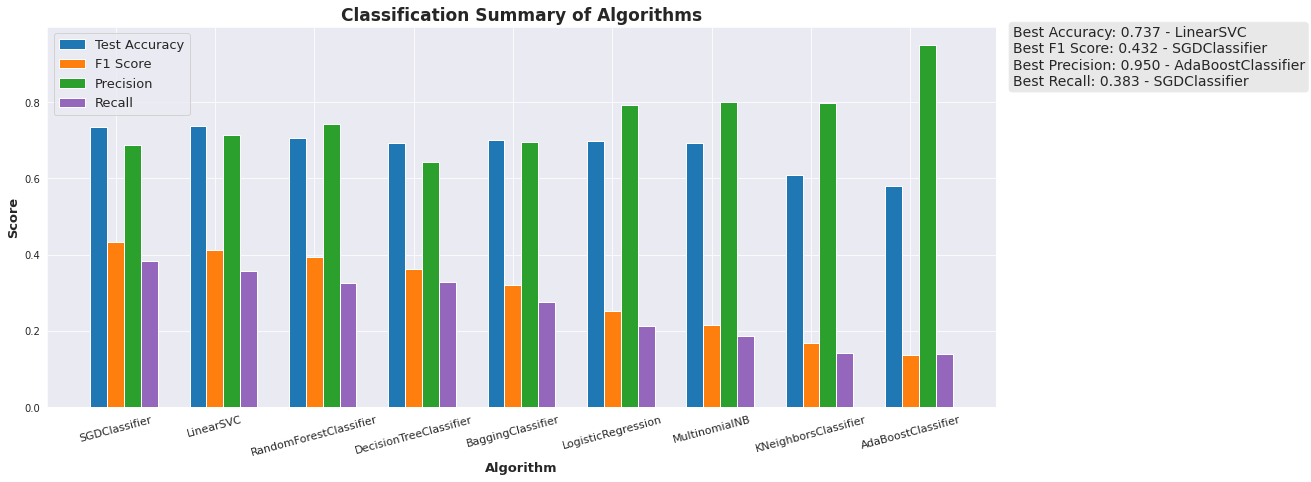

In [ ]:
sns.set_style('darkgrid')
plt.figure(figsize = (17, 7))

barWidth = 0.17

# set height of bar
bars1 = results['Accuracy: Test']
bars2 = results['F1 Score: Test']
bars3 = results['Precision: Test']
bars4 = results['Recall: Test']


# Set position of bar on X axis
r1 = np.arange(len(bars1))
r2 = [x + barWidth for x in r1]
r3 = [x + barWidth for x in r2]
r4 = [x + barWidth for x in r3]


# Make the plot
pal = sns.color_palette()
plt.bar(r1, bars1, color= pal[0], width=barWidth, edgecolor='white', label='Test Accuracy')
plt.bar(r2, bars2, color= pal[1], width=barWidth, edgecolor='white', label='F1 Score')
plt.bar(r3, bars3, color= pal[2], width=barWidth, edgecolor='white', label='Precision')
plt.bar(r4, bars4, color= pal[4], width=barWidth, edgecolor='white', label='Recall')


# Add xticks on the middle of the group bars
plt.xlabel('Algorithm', fontweight='bold', fontsize = 13)
plt.ylabel('Score', fontweight = 'bold', fontsize = 13)
plt.xticks([r + barWidth for r in range(len(bars1))], results['Algorithm'], rotation = 15, fontsize = 11)

# Create legend & Show graphic
plt.legend(fontsize = 13)

textstr = '\n'.join(['Best Accuracy: {:.3f} - {}'.format(best_acc['Accuracy: Test'].values[0], best_acc['Algorithm'].values[0]),
                     'Best F1 Score: {:.3f} - {}'.format(best_f1['F1 Score: Test'].values[0], best_f1['Algorithm'].values[0]),
                   'Best Precision: {:.3f} - {}'.format(best_precision['Precision: Test'].values[0], best_precision['Algorithm'].values[0]),
                    'Best Recall: {:.3f} - {}'.format(best_recall['Recall: Test'].values[0], best_recall['Algorithm'].values[0])])
props = dict(boxstyle='round', facecolor='lightgrey', alpha=0.5)

#place a text box
plt.text(9.2, 1, textstr, fontsize=14,
        verticalalignment='top', bbox=props)

plt.title('Classification Summary of Algorithms', fontweight = 'bold', fontsize = 17);

In [ ]:
# store the best/worst performance time
best_train_time = results[results['Training Time'] == results['Training Time'].min()]
worst_train_time = results[results['Training Time'] == results['Training Time'].max()]
best_prediction_time = results[results['Prediction Time'] == results['Prediction Time'].min()]
worst_prediction_time = results[results['Prediction Time'] == results['Prediction Time'].max()]

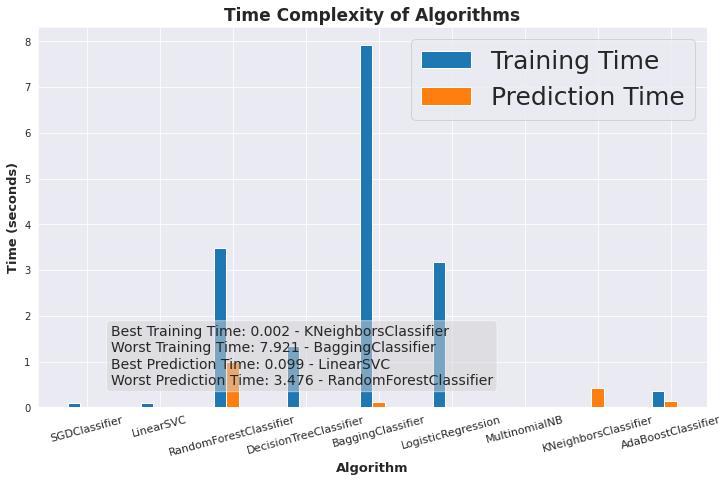

In [ ]:
plt.figure(figsize = (12, 7))

barWidth = 0.17

# set height of bar
bars1 = results['Training Time']
bars2 = results['Prediction Time']

# Set position of bar on X axis
r1 = np.arange(len(bars1))
r2 = [x + barWidth for x in r1]

# Make the plot
plt.bar(r1, bars1, color= pal[0], width=barWidth, edgecolor='white', label='Training Time')
plt.bar(r2, bars2, color= pal[1], width=barWidth, edgecolor='white', label='Prediction Time')

# Add xticks on the middle of the group bars
plt.xlabel('Algorithm', fontweight='bold', fontsize = 13)
plt.ylabel('Time (seconds)', fontweight = 'bold', fontsize = 13)
plt.xticks([r + barWidth for r in range(len(bars1))], results['Algorithm'], rotation = 15, fontsize = 11)

# Create legend & Show graphic
plt.legend(fontsize = 25)

textstr = '\n'.join(('Best Training Time: {:.3f} - {}'.format(best_train_time['Training Time'].values[0], best_train_time['Algorithm'].values[0]),
                     'Worst Training Time: {:.3f} - {}'.format(worst_train_time['Training Time'].values[0], worst_train_time['Algorithm'].values[0]),
                   'Best Prediction Time: {:.3f} - {}'.format(best_prediction_time['Training Time'].values[0], best_prediction_time['Algorithm'].values[0]),
                    'Worst Prediction Time: {:.3f} - {}'.format(worst_prediction_time['Training Time'].values[0], worst_prediction_time['Algorithm'].values[0])))

props = dict(boxstyle='round', facecolor='lightgrey', alpha=0.5)

#place a text box
plt.text(0.5, 0.5, textstr, fontsize=14,  bbox=props)

plt.title('Time Complexity of Algorithms', fontweight = 'bold', fontsize = 17);

### Tuning Hyperparameters
***

In [ ]:
def param_tuning(clf, param_dict, X_train, y_train, X_test, y_test):

    # make scorer object
    scorer = make_scorer(f1_score,average='macro')

    # perform Grid Search for Parameters
    grid_obj = GridSearchCV(estimator = clf,
                           param_grid = param_dict,
                           scoring = scorer,
                           cv = 5
                            )

    grid_fit = grid_obj.fit(X_train, y_train)

    # Get the estimator
    best_clf = grid_fit.best_estimator_

    # Make predictions using the unoptimized and model
    predictions = (clf.fit(X_train, y_train)).predict(X_test)
    best_predictions = best_clf.predict(X_test)

    # Report the before-and-afterscores
    print(clf.__class__.__name__)
    print("\nOptimized Model\n------")
    print("Best Parameters: {}".format(grid_fit.best_params_))
    print("Accuracy: {:.4f}".format(accuracy_score(y_test, best_predictions)))
    print("F1-score: {:.4f}".format(f1_score(y_test, best_predictions,average='macro')))
    print("Precision: {:.4f}".format(precision_score(y_test, best_predictions,average='macro')))
    print("Recall: {:.4f}".format(recall_score(y_test, best_predictions,average='macro')))

Stochastic Gradient Classifier:

In [ ]:
# Dict for parameters
average='macro'
param_grid = {
    'alpha' : [0.02,0.03,0.04,0.05,0.06,0.07,0.08,0.09,0.095, 0.0002, 0.0003,0.0004,0.0005,0.0006,0.0007],
    'max_iter' : [1000,2500, 3000, 4000,5000]
}

clf_sgd = SGDClassifier()

param_tuning(clf_sgd, param_grid, training_data, y_train, testing_data, y_test)

SGDClassifier

Optimized Model
------
Best Parameters: {'alpha': 0.0002, 'max_iter': 1000}
Accuracy: 0.7995
F1-score: 0.5273
Precision: 0.6261
Recall: 0.4773


Logistic Regression Classifier:

In [ ]:
# Dict for parameters
param_grid = {
    'C': [1, 1.2, 1.3, 1.4,1.5,1.6,1.7,1.8,1.9,2.0,2.1,2.2,2.3,2.4,2.5,2.6,2.7,2.8]
}

clf_lr = LogisticRegression()

param_tuning(clf_lr, param_grid, training_data, y_train, testing_data, y_test)

LogisticRegression

Optimized Model
------
Best Parameters: {'C': 2.8}
Accuracy: 0.7555
F1-score: 0.4145
Precision: 0.5873
Recall: 0.3623


Decision Tree Classifier:

In [ ]:
param_grid = {
    'min_samples_split': [2,3,4,5,6,7,8],
    'min_samples_leaf': [1,2,3,4,5,6,7,8]
}

clf_dt = DecisionTreeClassifier()

param_tuning(clf_dt, param_grid, training_data, y_train, testing_data, y_test)

DecisionTreeClassifier

Optimized Model
------
Best Parameters: {'min_samples_leaf': 1, 'min_samples_split': 4}
Accuracy: 0.7139
F1-score: 0.4200
Precision: 0.4513
Recall: 0.4386


Random Forest Classifier:

In [ ]:
param_grid = {
    'n_estimators': [25,50,75,100,125,150],
    'min_samples_leaf': [1,2,3,4,5],
    'min_samples_split': [2,3,4,5]
}

clf_rf = RandomForestClassifier()

param_tuning(clf_rf, param_grid, training_data, y_train, testing_data, y_test)

RandomForestClassifier

Optimized Model
------
Best Parameters: {'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 50}
Accuracy: 0.7267
F1-score: 0.6455
Precision: 0.8175
Recall: 0.5333


Linear SVC:

In [ ]:
param_grid = {
    'C': [0.05,0.1,0.2,0.3,0.4,0.5, 0.75, 1, 1.2]
}

clf_linsvc = LinearSVC()

param_tuning(clf_linsvc, param_grid, training_data, y_train, testing_data, y_test)

LinearSVC

Optimized Model
------
Best Parameters: {'C': 1.2}
Accuracy: 0.7506
F1-score: 0.5147
Precision: 0.5305
Recall: 0.5347


calculate the intensity of cyberbullying

In [ ]:
text='مانك مهضوم '
#word=' كتير عاهره']
import re
import nltk
nltk.download('punkt')
from nltk.tokenize import word_tokenize
def intensityofcyberbullying(text):
  text = re.sub("[إأآا]", "ا", text)
  text = re.sub("ة", "ه", text)
  list1=text.split()
  list2=stemming(list1)
  dfintensity['new'] =dfintensity.CyberbulledWord.isin(list2)
  dfintensity['new'].replace({False: 0, True: 1}, inplace=True)
  if  (dfintensity['new'] == 0).all():
    return ('0.0')
  else:
    intensity=dfintensity.groupby('new')['score'].sum()[1]
    if intensity>1:
      return ('تنمر مرتفع ، شدة التنمر '+str(1.0))
    elif intensity<=1 and intensity>=0.5:
      return ('تنمر مرتفع ، شدة التنمر '+str(round(intensity,1)))
    elif intensity<=0.4 and intensity>=0.3:
      return ('تنمر متوسط، شدة التنمر '+str(round(intensity,1)))
    elif intensity<=0.2 and intensity>=0.1:
      return ('تنمر منخفض، شدة التنمر '+str(round(intensity,1)))



[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [ ]:
print(intensityofcyberbullying('تافه وسخيف'))

تنمر مرتفع ، شدة التنمر 0.5


In [ ]:
! pip install owlready2

In [ ]:
import re
import nltk
nltk.download('punkt')
from nltk.tokenize import word_tokenize
from owlready2 import *
def search(text):
  onto = get_ontology("file:///content/ARCyberbulling.owl")
  onto.load()
  text = re.sub("[إأآا]", "ا", text)
  text = re.sub("ة", "ه", text)
  list1=text.split()
  list=stemming(list1)
  text1=removeStopWords(list)
  text2=text1.replace(" ", "_")
  for i in onto.individuals():
   test= str(i).split(".")[1]
   if test in text2:
     return(str(type(i)).split('.')[1])




[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [ ]:
print(search('العين الطراقة تطرقكن طرق'))

تنمر_بدعاء_على_الشخص


* Owlready2 * Warning: ignoring cyclic type of, involving storid 307

* Owlready2 * Warning: ignoring cyclic type of, involving storid 309

* Owlready2 * Warning: ignoring cyclic type of, involving storid 325

* Owlready2 * Warning: ignoring cyclic type of, involving storid 327

* Owlready2 * Warning: ignoring cyclic type of, involving storid 328



Importing Flask and ngrok to build the Web App:

In [ ]:
!pip install flask_ngrok

In [ ]:
!pip install flask

In [ ]:
!pip install pyngrok

web application using Flask and ngrok

In [ ]:
import flask
from flask import Flask, render_template, request
import pickle
import numpy as np
from pyngrok import ngrok
from flask_ngrok import run_with_ngrok
import warnings
warnings.filterwarnings('ignore')
import re
import nltk
nltk.download('punkt')
from nltk.tokenize import word_tokenize

app = Flask(__name__)
run_with_ngrok(app)

model = pickle.load(open('model.pkl', 'rb'))
@app.route('/', methods=['GET',"POST"])
def home():
  return render_template('index.html')

@app.route('/predict', methods=['GET', "POST"])
def predict():
  #selectValue = request.form.get('select1')
  #algorithm= str(selectValue)
  #if "predict" in request.form:
   text_values=request.form['text']
   input_values=request.form['text']
   input_values1=remove_diacritics(input_values)
   input_values2=clean_digits(input_values1)
   input_values3=clean_mensions(input_values2)
   input_values4=normalize_arabic(input_values3)
   input_values5=remove_punctuations(input_values4)
   input_values6=remove_repeating_char(input_values5)
   input_values7=clean_symbols(input_values6)
   input_values8=clean_nonarabic(input_values7)
   input_values9=clean_Emoji(input_values8)
   input_values10=tokenize_text(input_values9)
   input_values11=stemming(input_values10)
   input_values12=removeStopWords(input_values11)
   global algo
   algo = request.form.get("algo")
  #input_values = request.args.get('text')
   test_phrase = [input_values12]
   test_phrase_counts = count_vector.transform(test_phrase)
   global test_phrase_preds
   if algo=="SVM":
     test_phrase_preds = model.predict(test_phrase_counts)
   elif algo=="MultinomialNB":
      test_phrase_preds = modelMultinomialNB.predict(test_phrase_counts)
   elif algo=="DecisionTree":
      test_phrase_preds = modelDecisionTree.predict(test_phrase_counts)
   elif algo=="KNeighbors":
      test_phrase_preds = modelKNeighbors.predict(test_phrase_counts)
   elif algo=="Logistic":
      test_phrase_preds = modelRegression.predict(test_phrase_counts)
   elif algo=="RandomForest":
      test_phrase_preds = modelforest.predict(test_phrase_counts)
   elif algo=="SGDClassifier":
      test_phrase_preds = modelsgd.predict(test_phrase_counts)
   elif algo=="AdaBoostClassifier":
      test_phrase_preds = modelAdaBoost.predict(test_phrase_counts)
   elif algo=="BaggingClassifier":
      test_phras_preds = modelBagging.predict(test_phrase_counts)
   elif algo=="Stem" and request.form['stem'] == 'stemming':
          return render_template('index.html', prediction_text=input_values12)
   elif algo=="Ontology" and request.form['predict'] == 'prediction':
          return render_template('index.html', prediction_text=search(input_values12))

   if test_phrase_preds == 0 and request.form['predict'] == 'prediction':
        return render_template('index.html', prediction_text= '0.0 =ليس تنمر، شدة التنمر')
   elif test_phrase_preds == 1 and request.form['predict'] == 'prediction':
         return render_template('index.html', prediction_text=' تنمر عام' +'، '+str (intensityofcyberbullying(input_values12)))
   elif test_phrase_preds == 2 and request.form['predict'] == 'prediction':
         return render_template('index.html', prediction_text=' تنمر بدعاء على الشخص '+'، '+str (intensityofcyberbullying(input_values12)))
   elif test_phrase_preds == 3 and request.form['predict'] == 'prediction':
         return render_template('index.html', prediction_text= 'تنمر على الشكل بتشبيه الإنسان بحيوان أو شيء ما  '+'، '+str(intensityofcyberbullying(input_values12)))
   elif test_phrase_preds == 4 and request.form['predict'] == 'prediction':
          return render_template('index.html', prediction_text='تنمر حضاري '+'، '+str (intensityofcyberbullying(input_values12)))
   elif test_phrase_preds == 5 and request.form['predict'] == 'prediction':
          return render_template('index.html', prediction_text=' تنمر جنسي '+'، '+str (intensityofcyberbullying(input_values12)))
   elif test_phrase_preds == 6 and request.form['predict'] == 'prediction':
          return render_template('index.html', prediction_text=' تنمر جنسي فيزيائي  '+'، '+str (intensityofcyberbullying(input_values12)))
   elif test_phrase_preds == 7 and request.form['predict'] == 'prediction':
          return render_template('index.html', prediction_text='تنمر ديني '+'، '+str (intensityofcyberbullying(input_values12)))
   elif test_phrase_preds == 8 and request.form['predict'] == 'prediction':
          return render_template('index.html', prediction_text='تنمر طائفي '+'، '+str (intensityofcyberbullying(input_values12)))
   elif test_phrase_preds == 9 and request.form['predict'] == 'prediction':
          return render_template('index.html', prediction_text='تنمر عرقي'+'، '+str (intensityofcyberbullying(input_values12)))
   elif test_phrase_preds == 10 and request.form['predict'] == 'prediction':
          return render_template('index.html', prediction_text=' تنمر عنصري'+'، '+str (intensityofcyberbullying(input_values12)))
   elif test_phrase_preds == 11 and request.form['predict'] == 'prediction':
          return render_template('index.html', prediction_text='تنمر سياسي '+'، '+str (intensityofcyberbullying(input_values12)))
   elif test_phrase_preds == 12 and request.form['predict'] == 'prediction':
          return render_template('index.html', prediction_text='تنمر نفسي '+'، '+str (intensityofcyberbullying(input_values12)))




[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [ ]:
!ngrok authtoken 25RBB7Ntxd2D4R2rcYSUkDi2cU1_4jHGCYTaC4MAXDJU1R5kn

Authtoken saved to configuration file: /root/.ngrok2/ngrok.yml


In [ ]:
app.run()

 * Serving Flask app "__main__" (lazy loading)
 * Environment: production
   Use a production WSGI server instead.
 * Debug mode: off


 * Running on http://127.0.0.1:5000/ (Press CTRL+C to quit)


 * Running on http://cfae-34-90-149-168.ngrok.io
 * Traffic stats available on http://127.0.0.1:4040


In [ ]:
def stemming1(text):
  text=stemming(text)
  text=removeStopWords(text)
  list=text
  return list


In [ ]:
print(stemming1('انتو ناس كلاب'))